# Pre-cleaning

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('data/all_dec_data.csv')
df.drop(columns=['brand', 'cleaned_title'], inplace=True)

/var/folders/67/wknnxysn29s5zc375pft99140000gn/T/ipykernel_73816/2647319750.py:1: DtypeWarning: Columns (0: own_brand) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/all_dec_data.csv')


In [5]:
df['category'].value_counts()

category
food_cupboard      26670
home               22396
health_products    21309
fresh_food         14837
drinks             13620
household           6672
frozen              3951
baby_products       3818
pets                3703
free-from           3682
bakery              2713
Name: count, dtype: int64

In [7]:
# Filter df by specified categories
categories_to_keep = ['bakery', 'drinks', 'food_cupboard', 'free-from', 'fresh_food', 'frozen']
df_filtered = df[df['category'].isin(categories_to_keep)]

In [9]:
df_filtered.to_csv('data/raw.csv', index=False)

# EDA

In [3]:
import pandas as pd

df = pd.read_csv('data/raw.csv')

In [4]:
# Check the filtered dataframe statistics
print(f"Original dataframe shape: {df.shape}")
print(f"Filtered dataframe shape: {df.shape}")

print(df.columns)

Original dataframe shape: (65473, 8)
Filtered dataframe shape: (65473, 8)
Index(['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date',
       'category', 'own_brand'],
      dtype='str')


In [5]:
df["category"].value_counts()

category
food_cupboard    26670
fresh_food       14837
drinks           13620
frozen            3951
free-from         3682
bakery            2713
Name: count, dtype: int64

In [6]:
df["own_brand"].value_counts()

own_brand
False    44777
True     20695
Name: count, dtype: int64

In [7]:
df["unit"].value_counts()

unit
kg      44071
l       15097
unit     6292
m           4
Name: count, dtype: int64

In [8]:
# EDA
print(df.columns)

print("Shape: ", df.shape)

for col in df.columns:
    print(col)
    print(df[col].value_counts())
    print("\n")

Index(['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date',
       'category', 'own_brand'],
      dtype='str')
Shape:  (65473, 8)
supermarket
supermarket
Sains        17974
ASDA         17206
Tesco        15831
Morrisons    14462
Name: count, dtype: int64


prices_(£)
prices_(£)
2.00     3810
2.50     3194
1.50     2973
3.00     2753
1.00     2456
         ... 
10.76       1
7.85        1
11.07       1
75.00       1
3.06        1
Name: count, Length: 819, dtype: int64


prices_unit_(£)
prices_unit_(£)
5.00     1226
10.00    1168
4.00      873
2.00      758
8.00      688
         ... 
44.68       1
30.24       1
69.23       1
19.53       1
20.43       1
Name: count, Length: 2819, dtype: int64


unit
unit
kg      44071
l       15097
unit     6292
m           4
Name: count, dtype: int64


names
names
Tassimo Costa Latte Coffee Pods x6                         3
Tassimo Costa Cappuccino Coffee Pods x6                    3
Paxo Potato Rosti Cakes Mixed Veg 120g          

In [9]:
df['is_truncated'] = df['names'].astype(str).str.endswith('...') | df['names'].astype(str).str.endswith('…')
df[df['is_truncated']].head(5)

,supermarket,prices_(£),prices_unit_(£),unit,names,date,category,own_brand,is_truncated
17215,Morrisons,1.75,3.50,kg,Alpro Strawberry-Banana & Peach-P…,20240413,free-from,False,True
17216,Morrisons,3.25,8.13,kg,Morrisons The Best Thick Pork…,20240413,free-from,True,True
17218,Morrisons,2.50,8.30,l,"Twister Mini Pineapple,Lemon-Lime…",20240413,free-from,False,True
17219,Morrisons,1.25,0.21,unit,Mrs Crimble's Gluten Free 6 Big…,20240413,free-from,False,True
17220,Morrisons,3.25,8.67,kg,Morrisons The Best Cumberland Chi…,20240413,free-from,True,True


In [15]:
df['names'].sample(200).to_csv('eda/random_200_names.txt', index=False, header=False)

# Extensive Name Analysis & Visualization

This section provides comprehensive exploratory data analysis focused on product names, including:
- Name length and structure analysis
- Word frequency and patterns
- Brand detection and analysis
- Supermarket-specific naming conventions
- Category-specific name patterns
- Truncation analysis
- Text preprocessing insights

In [22]:
# Import necessary libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

# Configure plotting
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the data if not already loaded
if 'df' not in locals():
    df = pd.read_csv('data/raw.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total unique product names: {df['names'].nunique()}")

Dataset shape: (65473, 11)
Total unique product names: 63275


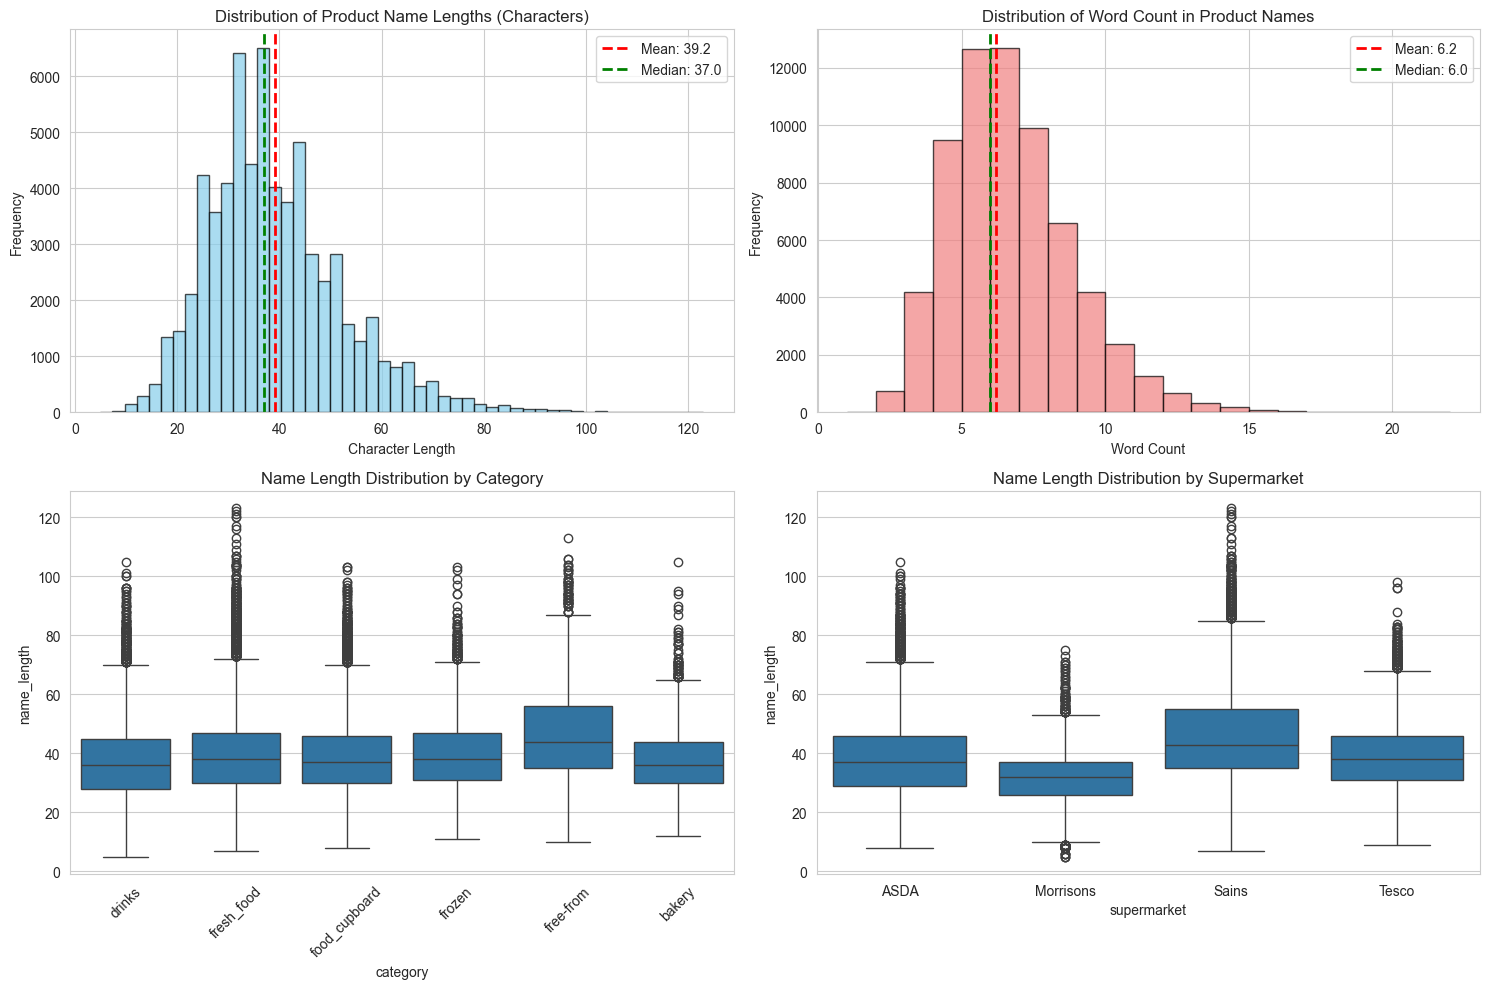


=== Name Length Statistics ===
Character Length - Mean: 39.19, Median: 37.00, Std: 13.35
Character Length - Min: 5.0, Max: 123.0

Word Count - Mean: 6.21, Median: 6.00, Std: 2.18
Word Count - Min: 1.0, Max: 21.0

=== Average Name Length by Category ===
category
free-from        46.397338
fresh_food       40.191965
frozen           40.074158
food_cupboard    38.447207
bakery           37.725028
drinks           37.628781
Name: name_length, dtype: float64

=== Average Name Length by Supermarket ===
supermarket
Sains        45.584845
Tesco        39.318742
ASDA         38.604940
Morrisons    31.786751
Name: name_length, dtype: float64


In [25]:
## 1. Name Length Analysis

# Calculate name length metrics
df['name_length'] = df['names'].str.len()
df['word_count'] = df['names'].str.split().str.len()

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character length distribution
axes[0, 0].hist(df['name_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Product Name Lengths (Characters)')
axes[0, 0].axvline(df['name_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["name_length"].mean():.1f}')
axes[0, 0].axvline(df['name_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["name_length"].median():.1f}')
axes[0, 0].legend()

# Word count distribution
max_words = int(df['word_count'].max()) 
axes[0, 1].hist(df['word_count'], bins=range(1, max_words + 2), color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Word Count in Product Names')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["word_count"].mean():.1f}')
axes[0, 1].axvline(df['word_count'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["word_count"].median():.1f}')
axes[0, 1].legend()

# Box plot by category
category_length = df.groupby('category')['name_length'].apply(list)
sns.boxplot(data=df, x='category', y='name_length', ax=axes[1, 0])
axes[1, 0].set_title('Name Length Distribution by Category')
axes[1, 0].tick_params(axis='x', rotation=45)

# Box plot by supermarket
supermarket_length = df.groupby('supermarket')['name_length'].apply(list)
sns.boxplot(data=df, x='supermarket', y='name_length', ax=axes[1, 1])
axes[1, 1].set_title('Name Length Distribution by Supermarket')

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== Name Length Statistics ===")
print(f"Character Length - Mean: {df['name_length'].mean():.2f}, Median: {df['name_length'].median():.2f}, Std: {df['name_length'].std():.2f}")
print(f"Character Length - Min: {df['name_length'].min()}, Max: {df['name_length'].max()}")
print(f"\nWord Count - Mean: {df['word_count'].mean():.2f}, Median: {df['word_count'].median():.2f}, Std: {df['word_count'].std():.2f}")
print(f"Word Count - Min: {df['word_count'].min()}, Max: {df['word_count'].max()}")

print("\n=== Average Name Length by Category ===")
print(df.groupby('category')['name_length'].mean().sort_values(ascending=False))

print("\n=== Average Name Length by Supermarket ===")
print(df.groupby('supermarket')['name_length'].mean().sort_values(ascending=False))

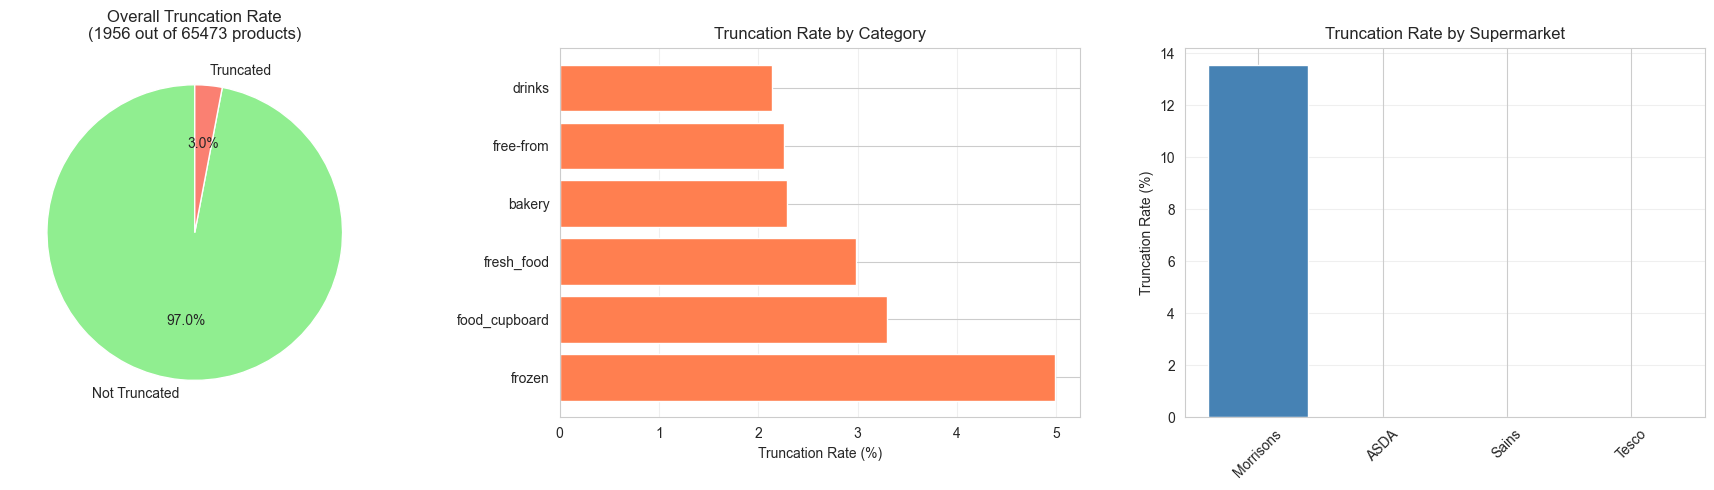


=== Truncation Statistics ===
Total truncated names: 1956 (2.99%)

Truncation by Category:
               sum  count  percentage
category                             
frozen         197   3951    4.986079
food_cupboard  880  26670    3.299588
fresh_food     443  14837    2.985779
bakery          62   2713    2.285293
free-from       83   3682    2.254210
drinks         291  13620    2.136564

Truncation by Supermarket:
              sum  count  percentage
supermarket                         
Morrisons    1956  14462     13.5251
ASDA            0  17206      0.0000
Sains           0  17974      0.0000
Tesco           0  15831      0.0000

=== Sample Truncated Names ===
                                    names   category supermarket
17215  Alpro Strawberry-Banana & Peach-P…  free-from   Morrisons
17216      Morrisons The Best Thick Pork…  free-from   Morrisons
17218  Twister Mini Pineapple,Lemon-Lime…  free-from   Morrisons
17219    Mrs Crimble's Gluten Free 6 Big…  free-from   Morriso

In [26]:
## 2. Truncation Analysis

# Detect truncated names (ending with ... or …)
if 'is_truncated' not in df.columns:
    df['is_truncated'] = df['names'].astype(str).str.endswith('...') | df['names'].astype(str).str.endswith('…')

# Calculate truncation statistics
truncation_rate = df['is_truncated'].sum() / len(df) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall truncation rate
truncation_counts = df['is_truncated'].value_counts()
axes[0].pie(truncation_counts, labels=['Not Truncated', 'Truncated'], autopct='%1.1f%%', 
            colors=['lightgreen', 'salmon'], startangle=90)
axes[0].set_title(f'Overall Truncation Rate\n({df["is_truncated"].sum()} out of {len(df)} products)')

# Truncation by category
truncation_by_category = df.groupby('category')['is_truncated'].agg(['sum', 'count'])
truncation_by_category['percentage'] = (truncation_by_category['sum'] / truncation_by_category['count'] * 100)
truncation_by_category = truncation_by_category.sort_values('percentage', ascending=False)

axes[1].barh(truncation_by_category.index, truncation_by_category['percentage'], color='coral')
axes[1].set_xlabel('Truncation Rate (%)')
axes[1].set_title('Truncation Rate by Category')
axes[1].grid(axis='x', alpha=0.3)

# Truncation by supermarket
truncation_by_supermarket = df.groupby('supermarket')['is_truncated'].agg(['sum', 'count'])
truncation_by_supermarket['percentage'] = (truncation_by_supermarket['sum'] / truncation_by_supermarket['count'] * 100)
truncation_by_supermarket = truncation_by_supermarket.sort_values('percentage', ascending=False)

axes[2].bar(truncation_by_supermarket.index, truncation_by_supermarket['percentage'], color='steelblue')
axes[2].set_ylabel('Truncation Rate (%)')
axes[2].set_title('Truncation Rate by Supermarket')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Truncation Statistics ===")
print(f"Total truncated names: {df['is_truncated'].sum()} ({truncation_rate:.2f}%)")
print(f"\nTruncation by Category:")
print(truncation_by_category.sort_values('percentage', ascending=False))
print(f"\nTruncation by Supermarket:")
print(truncation_by_supermarket.sort_values('percentage', ascending=False))

# Show some examples of truncated names
print(f"\n=== Sample Truncated Names ===")
print(df[df['is_truncated']][['names', 'category', 'supermarket']].head(10))

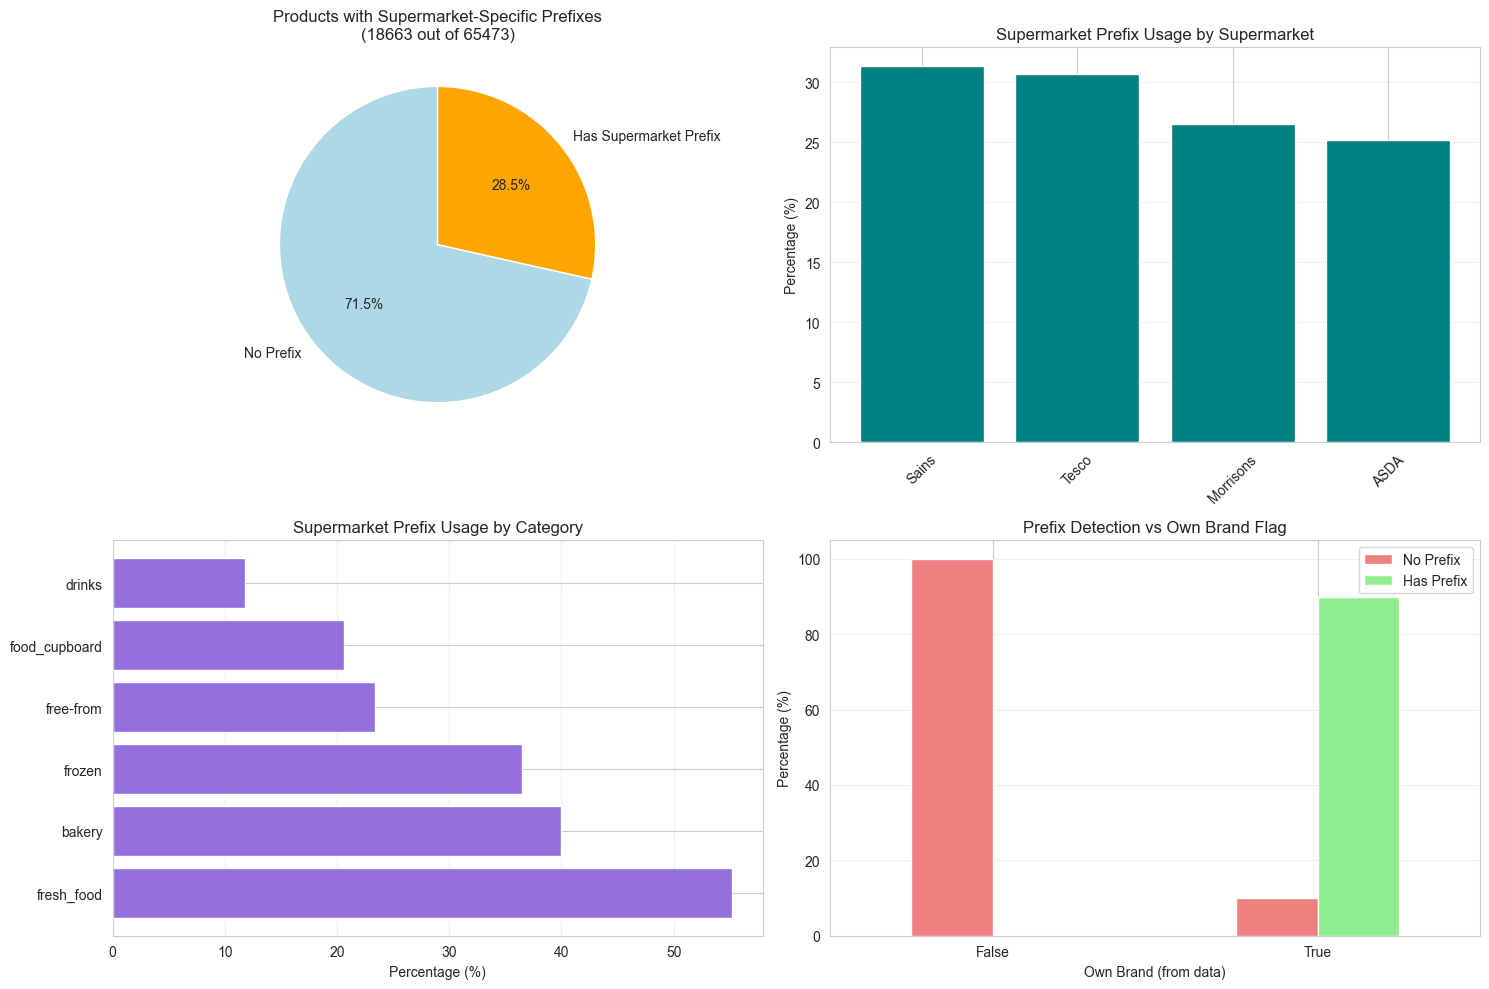


=== Supermarket Prefix Statistics ===
Total products with supermarket prefix: 18663 (28.50%)

Prefix Usage by Supermarket:
              sum  count  percentage
supermarket                         
Sains        5636  17974   31.356404
Tesco        4861  15831   30.705578
Morrisons    3834  14462   26.510856
ASDA         4332  17206   25.177264

Prefix Usage by Category:
                sum  count  percentage
category                              
fresh_food     8184  14837   55.159399
bakery         1083   2713   39.918909
frozen         1440   3951   36.446469
free-from       862   3682   23.411190
food_cupboard  5490  26670   20.584927
drinks         1604  13620   11.776799

=== Sample Products WITH Supermarket Prefixes ===
                                                names supermarket own_brand
3          ASDA Extra Special Brazilian Ground Coffee        ASDA      True
4            ASDA Extra Special Espresso Coffee Beans        ASDA      True
5             ASDA Extra Special Ken

In [27]:
## 3. Supermarket Brand Prefix Analysis

# Define common supermarket prefixes
supermarket_prefixes = {
    'Tesco': ['Tesco', 'Tesco Finest', 'Tesco Value', 'Tesco Everyday Value', 'Tesco Free From', 'Tesco Organic'],
    'ASDA': ['ASDA', 'Asda', 'ASDA Extra Special', 'Asda Smart Price', 'ASDA Free From', 'Asda Chosen By You'],
    'Morrisons': ['Morrisons', 'Morrisons The Best', 'Morrisons Savers', 'Morrisons Free From', 'M Kitchen'],
    'Sains': ['Sainsbury\'s', 'Sainsburys', 'Taste the Difference', 'Basics', 'Sainsbury Free From', 'SO Organic']
}

# Function to detect if name starts with supermarket prefix
def has_supermarket_prefix(name, supermarket):
    if pd.isna(name):
        return False
    name_lower = str(name).lower()
    prefixes = supermarket_prefixes.get(supermarket, [])
    return any(name_lower.startswith(prefix.lower()) for prefix in prefixes)

# Detect supermarket-branded products
df['has_own_prefix'] = df.apply(lambda row: has_supermarket_prefix(row['names'], row['supermarket']), axis=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall prefix usage
prefix_counts = df['has_own_prefix'].value_counts()
axes[0, 0].pie(prefix_counts, labels=['No Prefix', 'Has Supermarket Prefix'], autopct='%1.1f%%',
               colors=['lightblue', 'orange'], startangle=90)
axes[0, 0].set_title(f'Products with Supermarket-Specific Prefixes\n({df["has_own_prefix"].sum()} out of {len(df)})')

# Prefix usage by supermarket
prefix_by_supermarket = df.groupby('supermarket')['has_own_prefix'].agg(['sum', 'count'])
prefix_by_supermarket['percentage'] = (prefix_by_supermarket['sum'] / prefix_by_supermarket['count'] * 100)
prefix_by_supermarket = prefix_by_supermarket.sort_values('percentage', ascending=False)

axes[0, 1].bar(prefix_by_supermarket.index, prefix_by_supermarket['percentage'], color='teal')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Supermarket Prefix Usage by Supermarket')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Prefix usage by category
prefix_by_category = df.groupby('category')['has_own_prefix'].agg(['sum', 'count'])
prefix_by_category['percentage'] = (prefix_by_category['sum'] / prefix_by_category['count'] * 100)
prefix_by_category = prefix_by_category.sort_values('percentage', ascending=False)

axes[1, 0].barh(prefix_by_category.index, prefix_by_category['percentage'], color='mediumpurple')
axes[1, 0].set_xlabel('Percentage (%)')
axes[1, 0].set_title('Supermarket Prefix Usage by Category')
axes[1, 0].grid(axis='x', alpha=0.3)

# Relationship between own_brand and has_own_prefix
cross_tab = pd.crosstab(df['own_brand'], df['has_own_prefix'], normalize='index') * 100
cross_tab.plot(kind='bar', ax=axes[1, 1], color=['lightcoral', 'lightgreen'])
axes[1, 1].set_xlabel('Own Brand (from data)')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Prefix Detection vs Own Brand Flag')
axes[1, 1].legend(['No Prefix', 'Has Prefix'], loc='best')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Supermarket Prefix Statistics ===")
print(f"Total products with supermarket prefix: {df['has_own_prefix'].sum()} ({df['has_own_prefix'].sum()/len(df)*100:.2f}%)")
print(f"\nPrefix Usage by Supermarket:")
print(prefix_by_supermarket.sort_values('percentage', ascending=False))
print(f"\nPrefix Usage by Category:")
print(prefix_by_category.sort_values('percentage', ascending=False))

# Show examples of products with prefixes
print(f"\n=== Sample Products WITH Supermarket Prefixes ===")
print(df[df['has_own_prefix']][['names', 'supermarket', 'own_brand']].head(10))
print(f"\n=== Sample Products WITHOUT Supermarket Prefixes ===")
print(df[~df['has_own_prefix']][['names', 'supermarket', 'own_brand']].head(10))

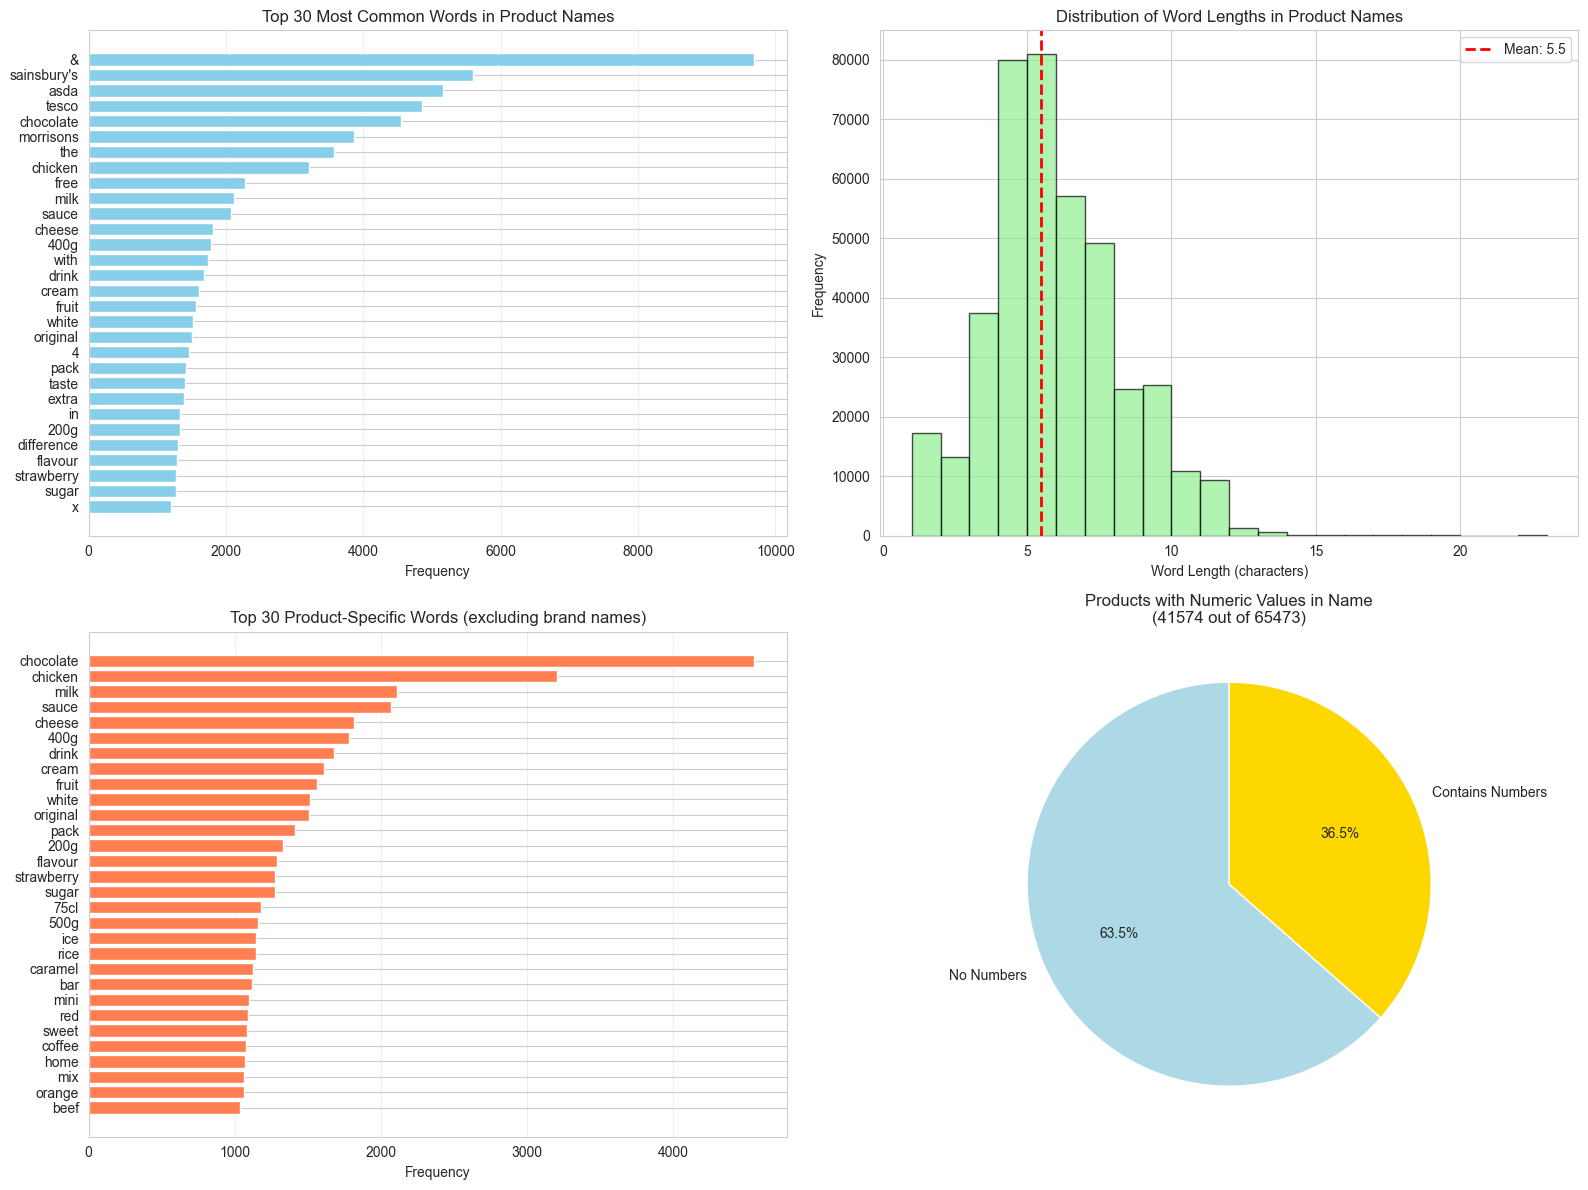


=== Word Frequency Statistics ===
Total words: 406620
Unique words: 16284
Average word length: 5.47 characters

=== Top 20 Most Common Words ===
 1. '&': 9,683 occurrences (2.38%)
 2. 'sainsbury's': 5,596 occurrences (1.38%)
 3. 'asda': 5,156 occurrences (1.27%)
 4. 'tesco': 4,860 occurrences (1.20%)
 5. 'chocolate': 4,550 occurrences (1.12%)
 6. 'morrisons': 3,861 occurrences (0.95%)
 7. 'the': 3,575 occurrences (0.88%)
 8. 'chicken': 3,205 occurrences (0.79%)
 9. 'free': 2,276 occurrences (0.56%)
10. 'milk': 2,110 occurrences (0.52%)
11. 'sauce': 2,070 occurrences (0.51%)
12. 'cheese': 1,813 occurrences (0.45%)
13. '400g': 1,782 occurrences (0.44%)
14. 'with': 1,738 occurrences (0.43%)
15. 'drink': 1,675 occurrences (0.41%)
16. 'cream': 1,610 occurrences (0.40%)
17. 'fruit': 1,565 occurrences (0.38%)
18. 'white': 1,517 occurrences (0.37%)
19. 'original': 1,510 occurrences (0.37%)
20. '4': 1,453 occurrences (0.36%)

=== Top 20 Product-Specific Terms (excluding brand names) ===
 1. 'c

In [28]:
## 4. Word Frequency Analysis

# Extract all words from product names
all_words = []
for name in df['names'].dropna():
    words = str(name).lower().split()
    all_words.extend(words)

# Count word frequencies
word_freq = Counter(all_words)
most_common_words = word_freq.most_common(50)

# Create dataframe for plotting
word_freq_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 30 most common words
top_30 = word_freq_df.head(30)
axes[0, 0].barh(top_30['Word'][::-1], top_30['Frequency'][::-1], color='skyblue')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Top 30 Most Common Words in Product Names')
axes[0, 0].grid(axis='x', alpha=0.3)

# Word length distribution
word_lengths = [len(word) for word in all_words]
axes[0, 1].hist(word_lengths, bins=range(1, max(word_lengths)+1), color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Length (characters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Word Lengths in Product Names')
axes[0, 1].axvline(np.mean(word_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(word_lengths):.1f}')
axes[0, 1].legend()

# Filter out supermarket names and common stop words to find product-specific terms
stop_words = {'tesco', 'asda', 'morrisons', 'sainsbury\'s', 'sainsburys', 'the', 'a', 'an', 'and', 
              'or', 'of', 'in', 'with', 'finest', 'value', 'extra', 'special', 'taste', 'difference',
              'basics', 'savers', 'best', 'free', 'from', 'organic', 'chosen', 'by', 'you', 'smart', 
              'price', 'everyday', 'kitchen', 'so', '&'}

product_words = [word for word in all_words if word.lower() not in stop_words and len(word) > 2]
product_word_freq = Counter(product_words)
product_common = product_word_freq.most_common(30)
product_freq_df = pd.DataFrame(product_common, columns=['Word', 'Frequency'])

axes[1, 0].barh(product_freq_df['Word'][::-1], product_freq_df['Frequency'][::-1], color='coral')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_title('Top 30 Product-Specific Words (excluding brand names)')
axes[1, 0].grid(axis='x', alpha=0.3)

# Numeric pattern detection
numeric_pattern = df['names'].str.contains(r'\d+', na=False)
numeric_counts = numeric_pattern.value_counts()
axes[1, 1].pie(numeric_counts, labels=['No Numbers', 'Contains Numbers'], autopct='%1.1f%%',
               colors=['lightblue', 'gold'], startangle=90)
axes[1, 1].set_title(f'Products with Numeric Values in Name\n({numeric_pattern.sum()} out of {len(df)})')

plt.tight_layout()
plt.show()

print("\n=== Word Frequency Statistics ===")
print(f"Total words: {len(all_words)}")
print(f"Unique words: {len(word_freq)}")
print(f"Average word length: {np.mean(word_lengths):.2f} characters")

print("\n=== Top 20 Most Common Words ===")
for i, (word, freq) in enumerate(most_common_words[:20], 1):
    print(f"{i:2d}. '{word}': {freq:,} occurrences ({freq/len(all_words)*100:.2f}%)")

print("\n=== Top 20 Product-Specific Terms (excluding brand names) ===")
for i, (word, freq) in enumerate(product_common[:20], 1):
    print(f"{i:2d}. '{word}': {freq:,} occurrences")

print(f"\n=== Numeric Patterns ===")
print(f"Products containing numbers: {numeric_pattern.sum()} ({numeric_pattern.sum()/len(df)*100:.2f}%)")

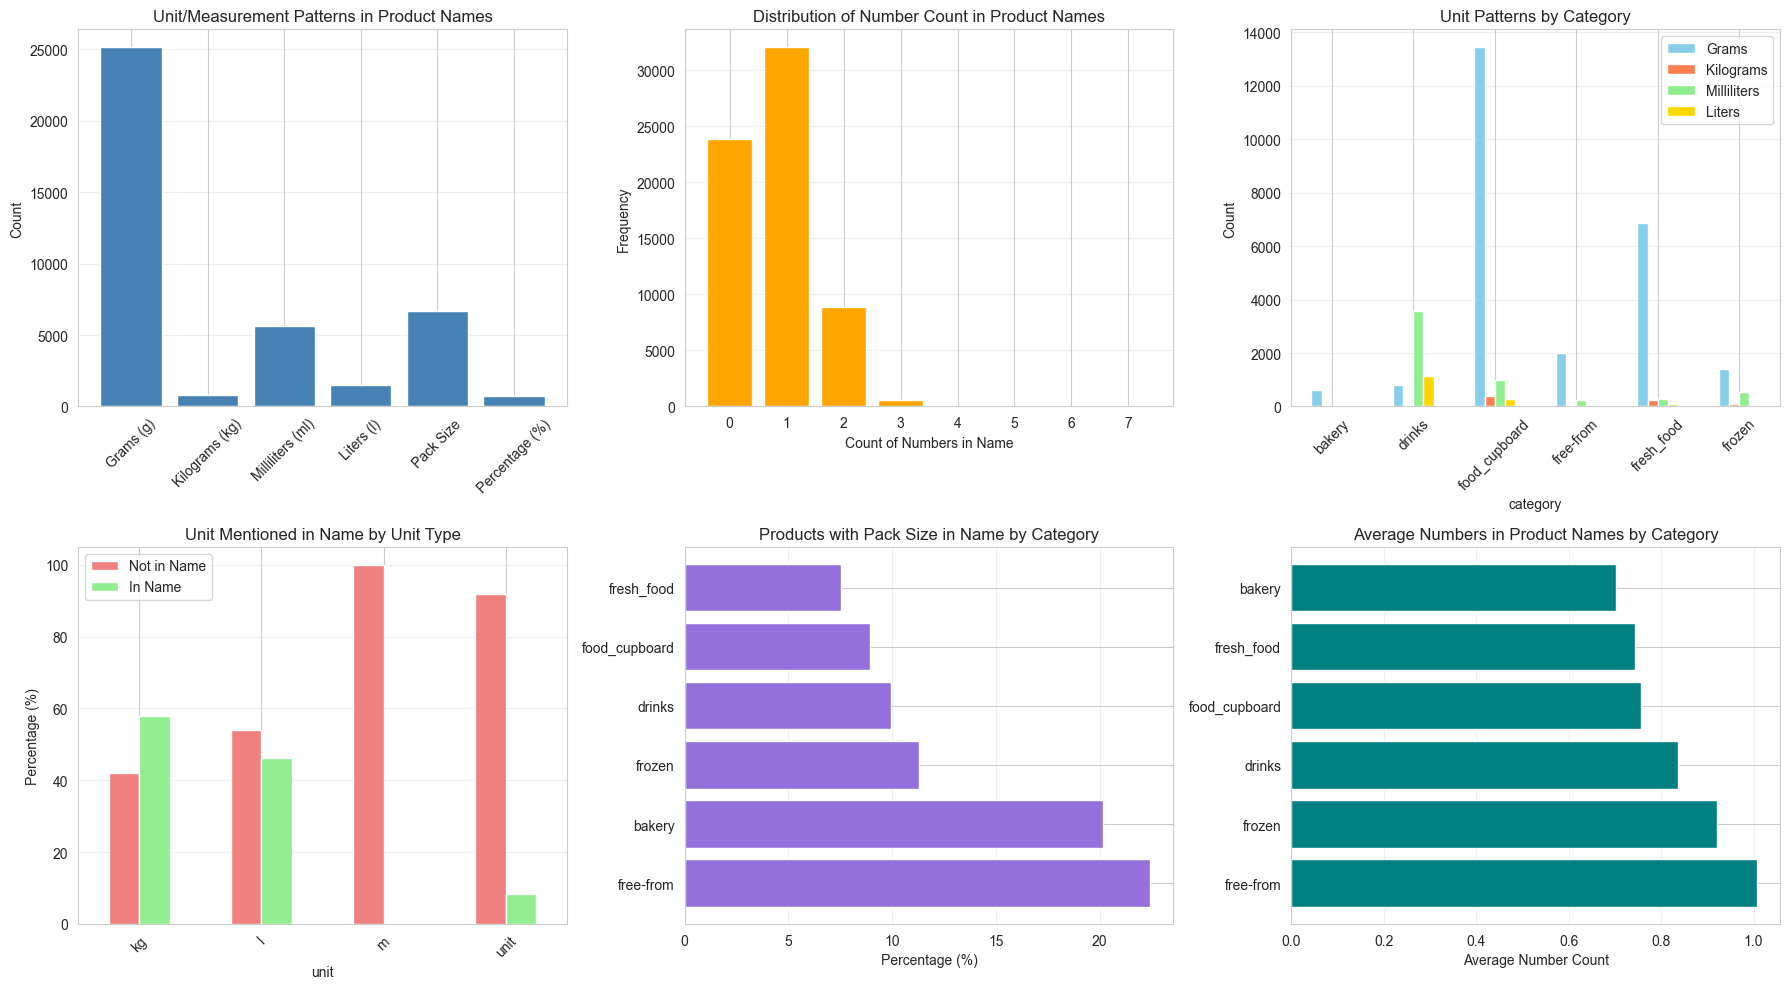


=== Unit Pattern Detection Statistics ===
Products with grams (g): 25120 (38.37%)
Products with kilograms (kg): 786 (1.20%)
Products with milliliters (ml): 5625 (8.59%)
Products with liters (l): 1537 (2.35%)
Products with pack size: 6673 (10.19%)
Products with percentage: 754 (1.15%)

=== Number Count in Names ===
Products with no numbers: 23899 (36.50%)
Products with 1+ numbers: 41574 (63.50%)
Average numbers per name: 0.79

=== Sample Products with Different Unit Patterns ===

With Grams:
                                                names unit
38  Taylors of Harrogate Hot Lava Java Ground Roas...   kg
48          Kenco Gold Indulgence Instant Coffee 195g   kg
63  ASDA Rich Roast Instant Coffee Granules Decaff...   kg

With Kilograms:
                                                names unit
429   Nestle Instant Full Cream Milk Powder 1.8kg Tin   kg
509                   Silver Spoon Demerara Sugar 1kg   kg
1003          ASDA Extra Special British Potatoes 2kg   kg

With Pack Siz

In [30]:
## 5. Unit/Weight/Volume Pattern Analysis in Names

# Extract unit patterns from product names
unit_patterns = {
    'grams': r'\d+\.?\d*\s*g(?:\s|$|,)',
    'kilograms': r'\d+\.?\d*\s*kg(?:\s|$|,)',
    'milliliters': r'\d+\.?\d*\s*ml(?:\s|$|,)',
    'liters': r'\d+\.?\d*\s*l(?:\s|$|,|itre)',
    'pack_size': r'x\d+|pack\s*of\s*\d+|\d+\s*pack',
    'percentage': r'\d+\.?\d*%'
}

# Detect patterns in names
for pattern_name, pattern in unit_patterns.items():
    df[f'has_{pattern_name}'] = df['names'].str.contains(pattern, case=False, na=False, regex=True)

# Use .str.len() directly on the result of findall; it handles NaN automatically
df['extracted_numbers'] = df['names'].str.findall(r'\d+\.?\d*')
df['number_count'] = df['extracted_numbers'].str.len().fillna(0).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Presence of different unit types
unit_detection = {
    'Grams (g)': df['has_grams'].sum(),
    'Kilograms (kg)': df['has_kilograms'].sum(),
    'Milliliters (ml)': df['has_milliliters'].sum(),
    'Liters (l)': df['has_liters'].sum(),
    'Pack Size': df['has_pack_size'].sum(),
    'Percentage (%)': df['has_percentage'].sum()
}

axes[0, 0].bar(unit_detection.keys(), unit_detection.values(), color='steelblue')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Unit/Measurement Patterns in Product Names')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Number count distribution
number_count_dist = df['number_count'].value_counts().sort_index()
axes[0, 1].bar(number_count_dist.index, number_count_dist.values, color='orange')
axes[0, 1].set_xlabel('Count of Numbers in Name')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Number Count in Product Names')
axes[0, 1].grid(axis='y', alpha=0.3)

# Unit patterns by category
unit_by_category = df.groupby('category')[['has_grams', 'has_kilograms', 'has_milliliters', 'has_liters']].sum()
unit_by_category.plot(kind='bar', ax=axes[0, 2], color=['skyblue', 'coral', 'lightgreen', 'gold'])
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Unit Patterns by Category')
axes[0, 2].legend(['Grams', 'Kilograms', 'Milliliters', 'Liters'], loc='best')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)

# Relationship between unit column and detected units in name
# Check if detected unit matches the unit column
df['unit_in_name'] = False
df.loc[df['has_grams'] | df['has_kilograms'], 'unit_in_name_type'] = 'weight'
df.loc[df['has_milliliters'] | df['has_liters'], 'unit_in_name_type'] = 'volume'
df['unit_in_name'] = df['has_grams'] | df['has_kilograms'] | df['has_milliliters'] | df['has_liters']

unit_match = pd.crosstab(df['unit'], df['unit_in_name'], normalize='index') * 100
unit_match.plot(kind='bar', ax=axes[1, 0], color=['lightcoral', 'lightgreen'])
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_title('Unit Mentioned in Name by Unit Type')
axes[1, 0].legend(['Not in Name', 'In Name'], loc='best')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Pack size mentions by category
pack_by_category = df.groupby('category')['has_pack_size'].agg(['sum', 'count'])
pack_by_category['percentage'] = (pack_by_category['sum'] / pack_by_category['count'] * 100)
pack_by_category = pack_by_category.sort_values('percentage', ascending=False)

axes[1, 1].barh(pack_by_category.index, pack_by_category['percentage'], color='mediumpurple')
axes[1, 1].set_xlabel('Percentage (%)')
axes[1, 1].set_title('Products with Pack Size in Name by Category')
axes[1, 1].grid(axis='x', alpha=0.3)

# Average numbers per name by category
avg_numbers = df.groupby('category')['number_count'].mean().sort_values(ascending=False)
axes[1, 2].barh(avg_numbers.index, avg_numbers.values, color='teal')
axes[1, 2].set_xlabel('Average Number Count')
axes[1, 2].set_title('Average Numbers in Product Names by Category')
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Unit Pattern Detection Statistics ===")
print(f"Products with grams (g): {df['has_grams'].sum()} ({df['has_grams'].sum()/len(df)*100:.2f}%)")
print(f"Products with kilograms (kg): {df['has_kilograms'].sum()} ({df['has_kilograms'].sum()/len(df)*100:.2f}%)")
print(f"Products with milliliters (ml): {df['has_milliliters'].sum()} ({df['has_milliliters'].sum()/len(df)*100:.2f}%)")
print(f"Products with liters (l): {df['has_liters'].sum()} ({df['has_liters'].sum()/len(df)*100:.2f}%)")
print(f"Products with pack size: {df['has_pack_size'].sum()} ({df['has_pack_size'].sum()/len(df)*100:.2f}%)")
print(f"Products with percentage: {df['has_percentage'].sum()} ({df['has_percentage'].sum()/len(df)*100:.2f}%)")

print(f"\n=== Number Count in Names ===")
print(f"Products with no numbers: {(df['number_count'] == 0).sum()} ({(df['number_count'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Products with 1+ numbers: {(df['number_count'] >= 1).sum()} ({(df['number_count'] >= 1).sum()/len(df)*100:.2f}%)")
print(f"Average numbers per name: {df['number_count'].mean():.2f}")

print(f"\n=== Sample Products with Different Unit Patterns ===")
print("\nWith Grams:")
print(df[df['has_grams']][['names', 'unit']].head(3))
print("\nWith Kilograms:")
print(df[df['has_kilograms']][['names', 'unit']].head(3))
print("\nWith Pack Size:")
print(df[df['has_pack_size']][['names']].head(3))

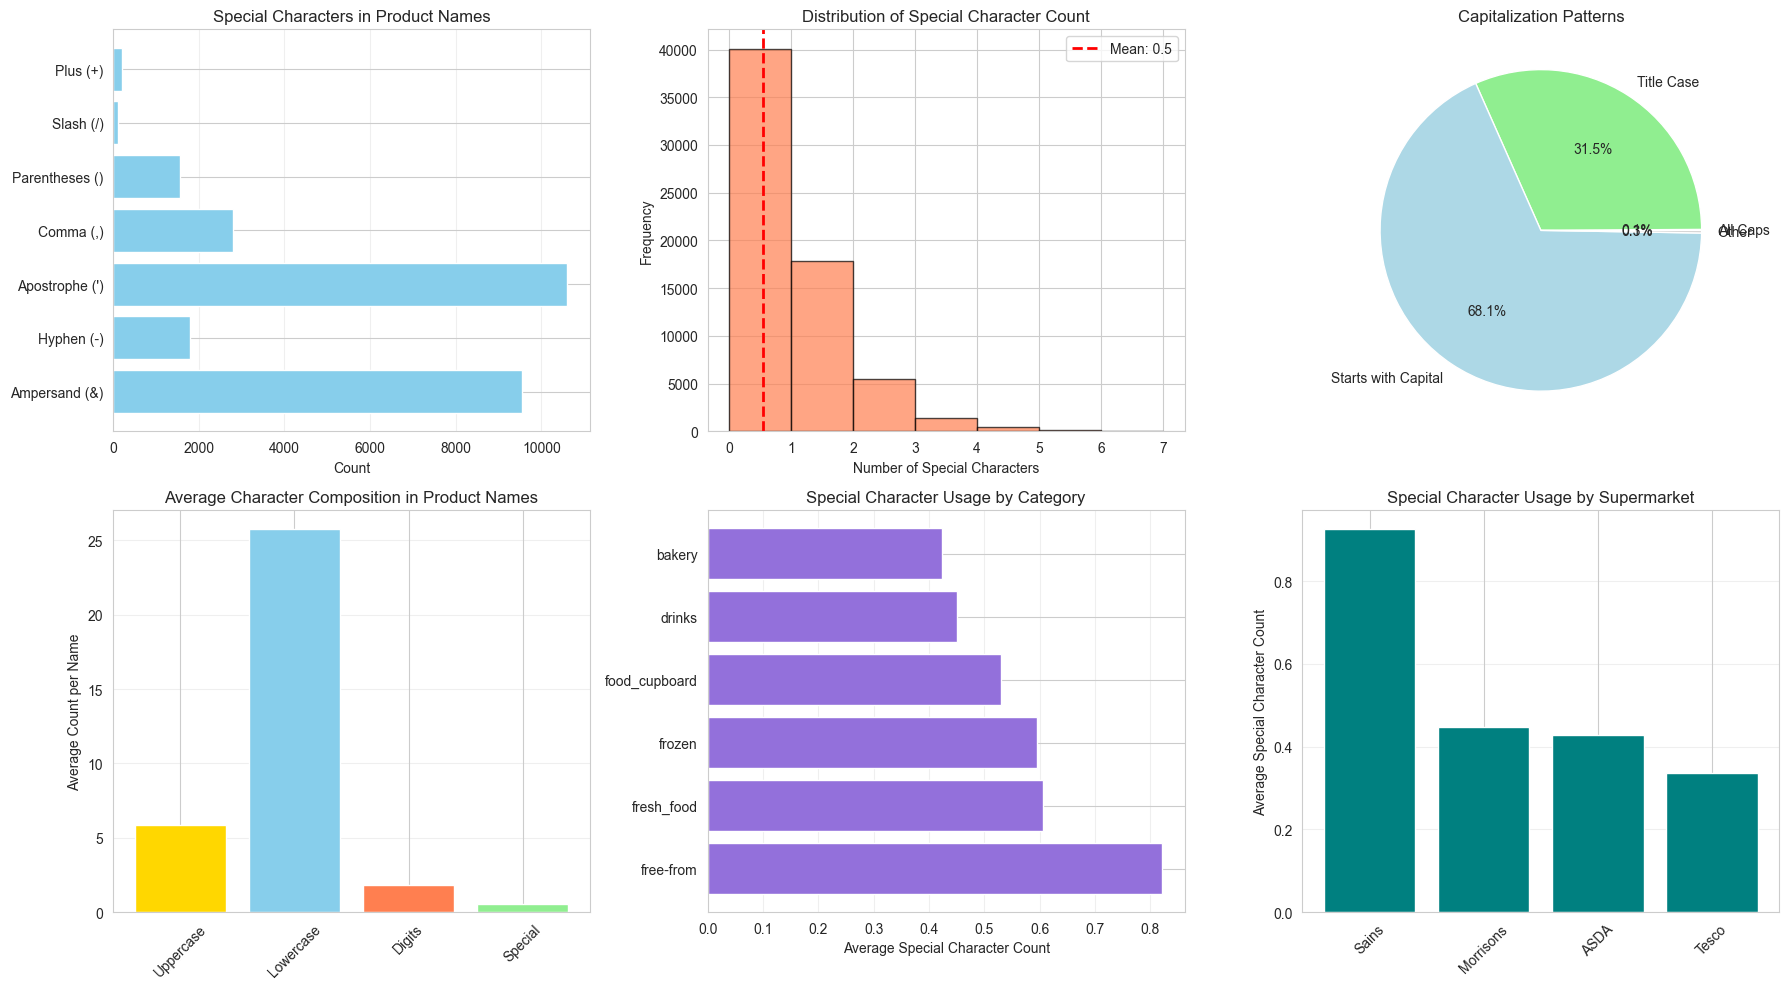


=== Special Character Statistics ===
Products with ampersand (&): 9546 (14.58%)
Products with hyphen (-): 1804 (2.76%)
Products with apostrophe ('): 10607 (16.20%)
Products with comma (,): 2802 (4.28%)
Products with parentheses (): 1570 (2.40%)
Products with slash (/): 119 (0.18%)
Products with plus (+): 221 (0.34%)

=== Capitalization Patterns ===
All caps: 95 (0.15%)
Title case: 30211 (46.14%)
Starts with capital: 65224 (99.62%)

=== Character Composition ===
Average uppercase letters: 5.86
Average lowercase letters: 25.76
Average digits: 1.82
Average special characters: 0.55

=== Sample Names with Many Special Characters (>5) ===
                                                   names  special_char_count
12864  Mars ,Maltesers, M&M's, Twix & More Fun Size M...                   6
15237  Guinness NitroSurge™ Device - Easy to Use - Po...                   7
32748  Sainsbury's Butter Beans Carton, SO Organic 38...                   6
37243  Sainsbury's Double Stuffed Halkidiki Olives

In [32]:
## 6. Character Pattern & Special Character Analysis

# Analyze character patterns
df['has_ampersand'] = df['names'].str.contains('&', na=False)
df['has_hyphen'] = df['names'].str.contains('-', na=False)
df['has_apostrophe'] = df['names'].str.contains("'", na=False)
df['has_comma'] = df['names'].str.contains(',', na=False)
df['has_parentheses'] = df['names'].str.contains(r'[\(\)]', na=False, regex=True)
df['has_slash'] = df['names'].str.contains('/', na=False)
df['has_plus'] = df['names'].str.contains(r'\+', na=False, regex=True)

# 1. Update the count calculations to handle NaN and ensure integer type
df['uppercase_count'] = df['names'].str.count(r'[A-Z]').fillna(0).astype(int)
df['lowercase_count'] = df['names'].str.count(r'[a-z]').fillna(0).astype(int)
df['digit_count'] = df['names'].str.count(r'\d').fillna(0).astype(int)
df['special_char_count'] = df['names'].str.count(r'[^A-Za-z0-9\s]').fillna(0).astype(int)

# 2. Fix the Histogram bins (Line 42)
max_spec_chars = int(df['special_char_count'].max())
axes[0, 1].hist(df['special_char_count'], bins=range(0, max_spec_chars + 2), 
                color='coral', edgecolor='black', alpha=0.7)
# Capitalization patterns
df['is_all_caps'] = df['names'].str.isupper()
df['is_title_case'] = df['names'].apply(lambda x: str(x).istitle() if pd.notna(x) else False)
df['starts_with_capital'] = df['names'].str[0].str.isupper()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Special character usage
special_chars = {
    'Ampersand (&)': df['has_ampersand'].sum(),
    'Hyphen (-)': df['has_hyphen'].sum(),
    'Apostrophe (\')': df['has_apostrophe'].sum(),
    'Comma (,)': df['has_comma'].sum(),
    'Parentheses ()': df['has_parentheses'].sum(),
    'Slash (/)': df['has_slash'].sum(),
    'Plus (+)': df['has_plus'].sum()
}

axes[0, 0].barh(list(special_chars.keys()), list(special_chars.values()), color='skyblue')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Special Characters in Product Names')
axes[0, 0].grid(axis='x', alpha=0.3)

# Distribution of special character count
axes[0, 1].hist(df['special_char_count'], bins=range(0, df['special_char_count'].max()+1), 
                color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Special Characters')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Special Character Count')
axes[0, 1].axvline(df['special_char_count'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["special_char_count"].mean():.1f}')
axes[0, 1].legend()

# Capitalization patterns
cap_patterns = {
    'All Caps': df['is_all_caps'].sum(),
    'Title Case': df['is_title_case'].sum(),
    'Starts with Capital': df['starts_with_capital'].sum(),
    'Other': len(df) - df['starts_with_capital'].sum()
}

axes[0, 2].pie([cap_patterns['All Caps'], cap_patterns['Title Case'], 
                cap_patterns['Starts with Capital'], cap_patterns['Other']], 
               labels=list(cap_patterns.keys()), autopct='%1.1f%%',
               colors=['gold', 'lightgreen', 'lightblue', 'lightgray'])
axes[0, 2].set_title('Capitalization Patterns')

# Character composition (stacked bar)
char_comp = pd.DataFrame({
    'Uppercase': df['uppercase_count'],
    'Lowercase': df['lowercase_count'],
    'Digits': df['digit_count'],
    'Special': df['special_char_count']
})

char_comp_mean = char_comp.mean()
axes[1, 0].bar(char_comp_mean.index, char_comp_mean.values, color=['gold', 'skyblue', 'coral', 'lightgreen'])
axes[1, 0].set_ylabel('Average Count per Name')
axes[1, 0].set_title('Average Character Composition in Product Names')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Special character usage by category
special_by_category = df.groupby('category')['special_char_count'].mean().sort_values(ascending=False)
axes[1, 1].barh(special_by_category.index, special_by_category.values, color='mediumpurple')
axes[1, 1].set_xlabel('Average Special Character Count')
axes[1, 1].set_title('Special Character Usage by Category')
axes[1, 1].grid(axis='x', alpha=0.3)

# Special character usage by supermarket
special_by_supermarket = df.groupby('supermarket')['special_char_count'].mean().sort_values(ascending=False)
axes[1, 2].bar(special_by_supermarket.index, special_by_supermarket.values, color='teal')
axes[1, 2].set_ylabel('Average Special Character Count')
axes[1, 2].set_title('Special Character Usage by Supermarket')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Special Character Statistics ===")
print(f"Products with ampersand (&): {df['has_ampersand'].sum()} ({df['has_ampersand'].sum()/len(df)*100:.2f}%)")
print(f"Products with hyphen (-): {df['has_hyphen'].sum()} ({df['has_hyphen'].sum()/len(df)*100:.2f}%)")
print(f"Products with apostrophe ('): {df['has_apostrophe'].sum()} ({df['has_apostrophe'].sum()/len(df)*100:.2f}%)")
print(f"Products with comma (,): {df['has_comma'].sum()} ({df['has_comma'].sum()/len(df)*100:.2f}%)")
print(f"Products with parentheses (): {df['has_parentheses'].sum()} ({df['has_parentheses'].sum()/len(df)*100:.2f}%)")
print(f"Products with slash (/): {df['has_slash'].sum()} ({df['has_slash'].sum()/len(df)*100:.2f}%)")
print(f"Products with plus (+): {df['has_plus'].sum()} ({df['has_plus'].sum()/len(df)*100:.2f}%)")

print(f"\n=== Capitalization Patterns ===")
print(f"All caps: {df['is_all_caps'].sum()} ({df['is_all_caps'].sum()/len(df)*100:.2f}%)")
print(f"Title case: {df['is_title_case'].sum()} ({df['is_title_case'].sum()/len(df)*100:.2f}%)")
print(f"Starts with capital: {df['starts_with_capital'].sum()} ({df['starts_with_capital'].sum()/len(df)*100:.2f}%)")

print(f"\n=== Character Composition ===")
print(f"Average uppercase letters: {df['uppercase_count'].mean():.2f}")
print(f"Average lowercase letters: {df['lowercase_count'].mean():.2f}")
print(f"Average digits: {df['digit_count'].mean():.2f}")
print(f"Average special characters: {df['special_char_count'].mean():.2f}")

print(f"\n=== Sample Names with Many Special Characters (>5) ===")
print(df[df['special_char_count'] > 5][['names', 'special_char_count']].head(10))

=== TOP 10 WORDS BY CATEGORY ===


DRINKS (n=13620)
--------------------------------------------------
   1. 75cl                 ( 1169 occurrences)
   2. drink                ( 1019 occurrences)
   3. sugar                (  685 occurrences)
   4. beer                 (  651 occurrences)
   5. juice                (  642 occurrences)
   6. water                (  635 occurrences)
   7. coffee               (  612 occurrences)
   8. fruit                (  585 occurrences)
   9. bottle               (  579 occurrences)
  10. 500ml                (  578 occurrences)

FRESH_FOOD (n=14837)
--------------------------------------------------
   1. chicken              ( 1598 occurrences)
   2. cheese               ( 1129 occurrences)
   3. british              (  837 occurrences)
   4. 400g                 (  667 occurrences)
   5. pork                 (  615 occurrences)
   6. yogurt               (  546 occurrences)
   7. beef                 (  523 occurrences)
   8. 200g               

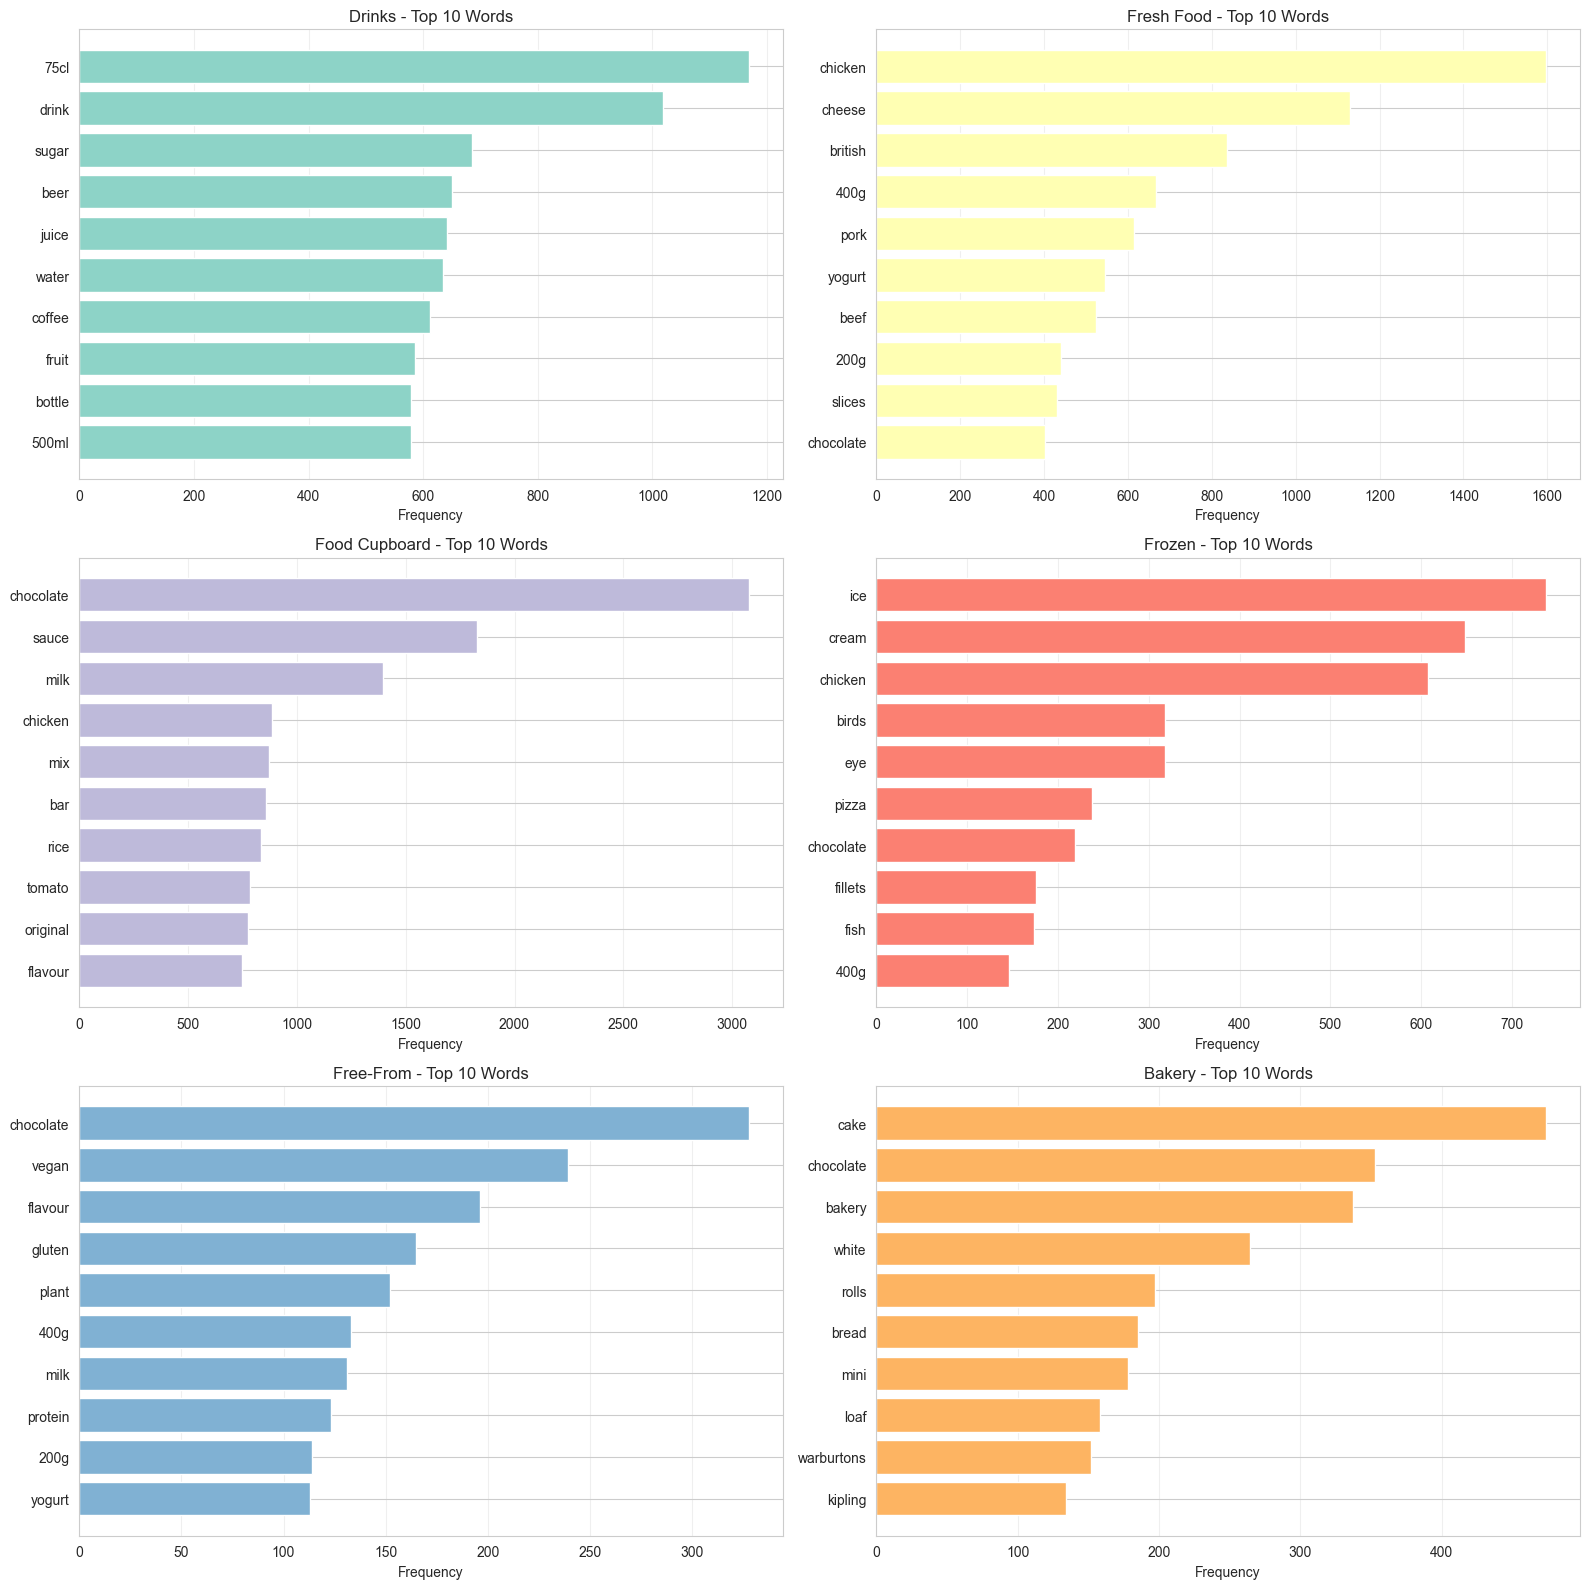



=== CATEGORY NAME STATISTICS ===
               name_length_mean  name_length_std  word_count_mean  \
category                                                            
food_cupboard             38.45            12.49             6.11   
fresh_food                40.19            14.22             6.33   
drinks                    37.63            12.97             5.97   
frozen                    40.07            12.92             6.49   
free-from                 46.40            16.19             7.17   
bakery                    37.73            11.17             6.11   

               word_count_std  special_char_count_mean  number_count_mean  \
category                                                                    
food_cupboard            2.08                     0.53               0.76   
fresh_food               2.34                     0.61               0.74   
drinks                   2.05                     0.45               0.84   
frozen                   2.

In [33]:
## 7. Category-Specific Name Pattern Analysis

# Analyze top words per category (excluding stop words)
stop_words = {'tesco', 'asda', 'morrisons', 'sainsbury\'s', 'sainsburys', 'the', 'a', 'an', 'and', 
              'or', 'of', 'in', 'with', 'finest', 'value', 'extra', 'special', 'taste', 'difference',
              'basics', 'savers', 'best', 'free', 'from', 'organic', 'chosen', 'by', 'you', 'smart', 
              'price', 'everyday', 'kitchen', 'so', '&', 'x', 'pack'}

categories = df['category'].unique()

print("=== TOP 10 WORDS BY CATEGORY ===\n")

category_top_words = {}

for category in categories:
    category_df = df[df['category'] == category]
    words = []
    for name in category_df['names'].dropna():
        words.extend([w.lower() for w in str(name).split() if w.lower() not in stop_words and len(w) > 2])
    
    word_freq = Counter(words)
    top_10 = word_freq.most_common(10)
    category_top_words[category] = top_10
    
    print(f"\n{category.upper()} (n={len(category_df)})")
    print("-" * 50)
    for i, (word, count) in enumerate(top_10, 1):
        print(f"  {i:2d}. {word:20s} ({count:5d} occurrences)")

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for idx, category in enumerate(categories):
    words, counts = zip(*category_top_words[category])
    axes[idx].barh(list(words)[::-1], list(counts)[::-1], color=plt.cm.Set3(idx))
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_title(f'{category.replace("_", " ").title()} - Top 10 Words')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze name statistics by category
category_stats = df.groupby('category').agg({
    'name_length': ['mean', 'std'],
    'word_count': ['mean', 'std'],
    'special_char_count': 'mean',
    'number_count': 'mean',
    'names': 'count'
}).round(2)

category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
category_stats = category_stats.sort_values('names_count', ascending=False)

print("\n\n=== CATEGORY NAME STATISTICS ===")
print(category_stats)

=== NAME UNIQUENESS STATISTICS ===
Total products: 65473
Unique product names: 63275
Duplicate names: 2150
Products with duplicate names: 4347
Uniqueness ratio: 96.64%

=== TOP 20 MOST DUPLICATED PRODUCT NAMES ===
names
Tassimo Costa Latte Coffee Pods x6                              3
Tassimo Costa Cappuccino Coffee Pods x6                         3
Paxo Potato Rosti Cakes Mixed Veg 120g                          3
Pukka Vegan Chicken & Mushroom Pie                              3
Pukka Beef Pasty 210g                                           3
Robinsons Ready to Drink Raspberry & Apple Juice Drink 500ml    3
Monster Energy Zero Sugar 500ml                                 3
Tropicana Pressed Apple Fruit Juice 1.5L                        3
Yeo Valley Organic Salted Butter 200g                           3
Sharwood's Medium Egg Noodles 226g                              3
Sharwood's Fine Egg Noodles 226g                                3
Fullgreen Riced Cauliflower & Broccoli 200g           

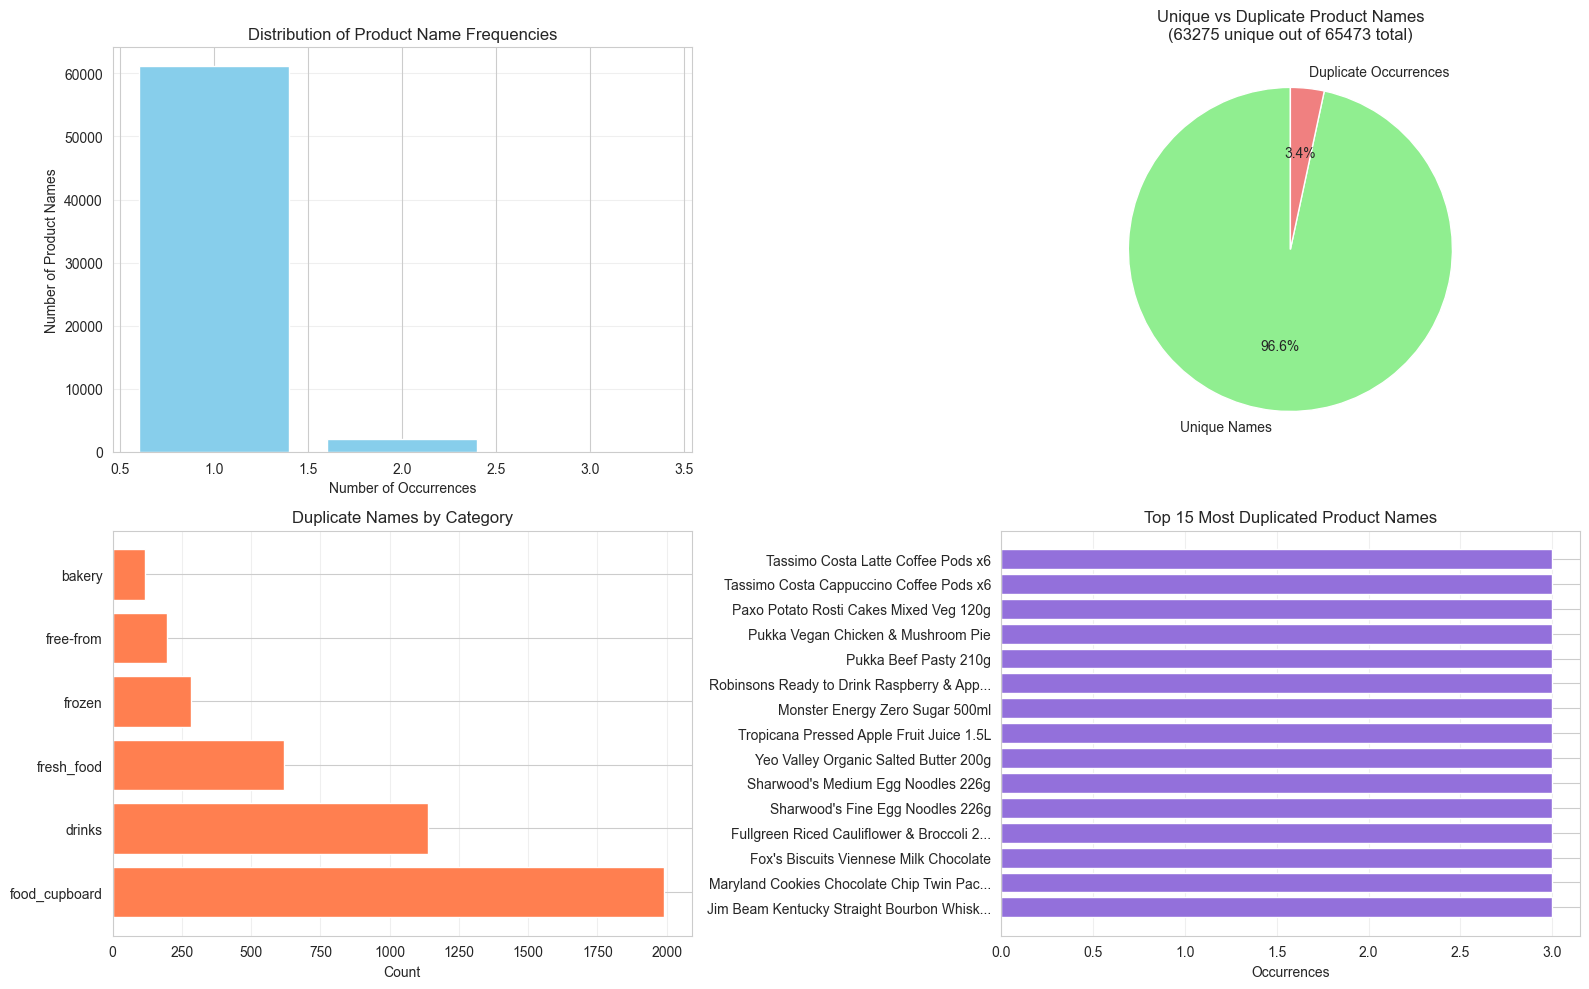


=== CROSS-SUPERMARKET DUPLICATE ANALYSIS ===
'Tassimo Costa Latte Coffee Pods x6' appears in: ASDA, Morrisons, Sains
'Tassimo Costa Cappuccino Coffee Pods x6' appears in: ASDA, Morrisons, Sains
'Paxo Potato Rosti Cakes Mixed Veg 120g' appears in: ASDA, Sains, Tesco
'Pukka Vegan Chicken & Mushroom Pie' appears in: ASDA, Morrisons, Tesco
'Pukka Beef Pasty 210g' appears in: ASDA, Sains, Tesco
'Robinsons Ready to Drink Raspberry & Apple Juice Drink 500ml' appears in: ASDA, Sains, Tesco
'Monster Energy Zero Sugar 500ml' appears in: ASDA, Sains, Tesco
'Tropicana Pressed Apple Fruit Juice 1.5L' appears in: ASDA, Sains, Tesco
'Yeo Valley Organic Salted Butter 200g' appears in: ASDA, Sains, Tesco
'Sharwood's Medium Egg Noodles 226g' appears in: ASDA, Sains, Tesco

Total duplicate names appearing in multiple supermarkets: 2150 (100.00% of duplicates)
Products with cross-supermarket names: 4347 (6.64% of all products)


In [34]:
## 8. Name Uniqueness & Similarity Analysis

# Analyze name duplication
name_counts = df['names'].value_counts()
duplicated_names = name_counts[name_counts > 1]

print(f"=== NAME UNIQUENESS STATISTICS ===")
print(f"Total products: {len(df)}")
print(f"Unique product names: {df['names'].nunique()}")
print(f"Duplicate names: {len(duplicated_names)}")
print(f"Products with duplicate names: {duplicated_names.sum()}")
print(f"Uniqueness ratio: {df['names'].nunique() / len(df) * 100:.2f}%")

# Analyze most duplicated names
print(f"\n=== TOP 20 MOST DUPLICATED PRODUCT NAMES ===")
print(duplicated_names.head(20))

# Check if duplicates are across supermarkets or within
print(f"\n=== SAMPLE DUPLICATE ANALYSIS ===")
for name in duplicated_names.head(5).index:
    print(f"\n'{name}' appears {duplicated_names[name]} times:")
    duplicate_df = df[df['names'] == name][['supermarket', 'prices_(£)', 'category', 'own_brand']]
    print(duplicate_df.to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution of name frequencies
freq_distribution = name_counts.value_counts().sort_index()
axes[0, 0].bar(freq_distribution.index[:20], freq_distribution.values[:20], color='skyblue')
axes[0, 0].set_xlabel('Number of Occurrences')
axes[0, 0].set_ylabel('Number of Product Names')
axes[0, 0].set_title('Distribution of Product Name Frequencies')
axes[0, 0].grid(axis='y', alpha=0.3)

# Pie chart of unique vs duplicate
unique_products = len(df) - duplicated_names.sum() + len(duplicated_names)
duplicate_products = duplicated_names.sum() - len(duplicated_names)
axes[0, 1].pie([unique_products, duplicate_products], 
               labels=['Unique Names', 'Duplicate Occurrences'],
               autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
axes[0, 1].set_title(f'Unique vs Duplicate Product Names\n({df["names"].nunique()} unique out of {len(df)} total)')

# Duplicates by category
duplicates_df = df[df['names'].isin(duplicated_names.index)]
dup_by_category = duplicates_df['category'].value_counts()
axes[1, 0].barh(dup_by_category.index, dup_by_category.values, color='coral')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title('Duplicate Names by Category')
axes[1, 0].grid(axis='x', alpha=0.3)

# Top duplicated names bar chart
top_dups = duplicated_names.head(15)
axes[1, 1].barh(range(len(top_dups)), top_dups.values[::-1], color='mediumpurple')
axes[1, 1].set_yticks(range(len(top_dups)))
axes[1, 1].set_yticklabels([name[:40] + '...' if len(name) > 40 else name for name in top_dups.index[::-1]])
axes[1, 1].set_xlabel('Occurrences')
axes[1, 1].set_title('Top 15 Most Duplicated Product Names')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze cross-supermarket duplicates
print(f"\n=== CROSS-SUPERMARKET DUPLICATE ANALYSIS ===")
for name in duplicated_names.head(10).index:
    supermarkets = df[df['names'] == name]['supermarket'].unique()
    if len(supermarkets) > 1:
        print(f"'{name[:60]}' appears in: {', '.join(supermarkets)}")

# Calculate percentage of names that appear in multiple supermarkets
cross_supermarket_names = []
for name in duplicated_names.index:
    if len(df[df['names'] == name]['supermarket'].unique()) > 1:
        cross_supermarket_names.append(name)

print(f"\nTotal duplicate names appearing in multiple supermarkets: {len(cross_supermarket_names)} "
      f"({len(cross_supermarket_names)/len(duplicated_names)*100:.2f}% of duplicates)")
print(f"Products with cross-supermarket names: {df['names'].isin(cross_supermarket_names).sum()} "
      f"({df['names'].isin(cross_supermarket_names).sum()/len(df)*100:.2f}% of all products)")

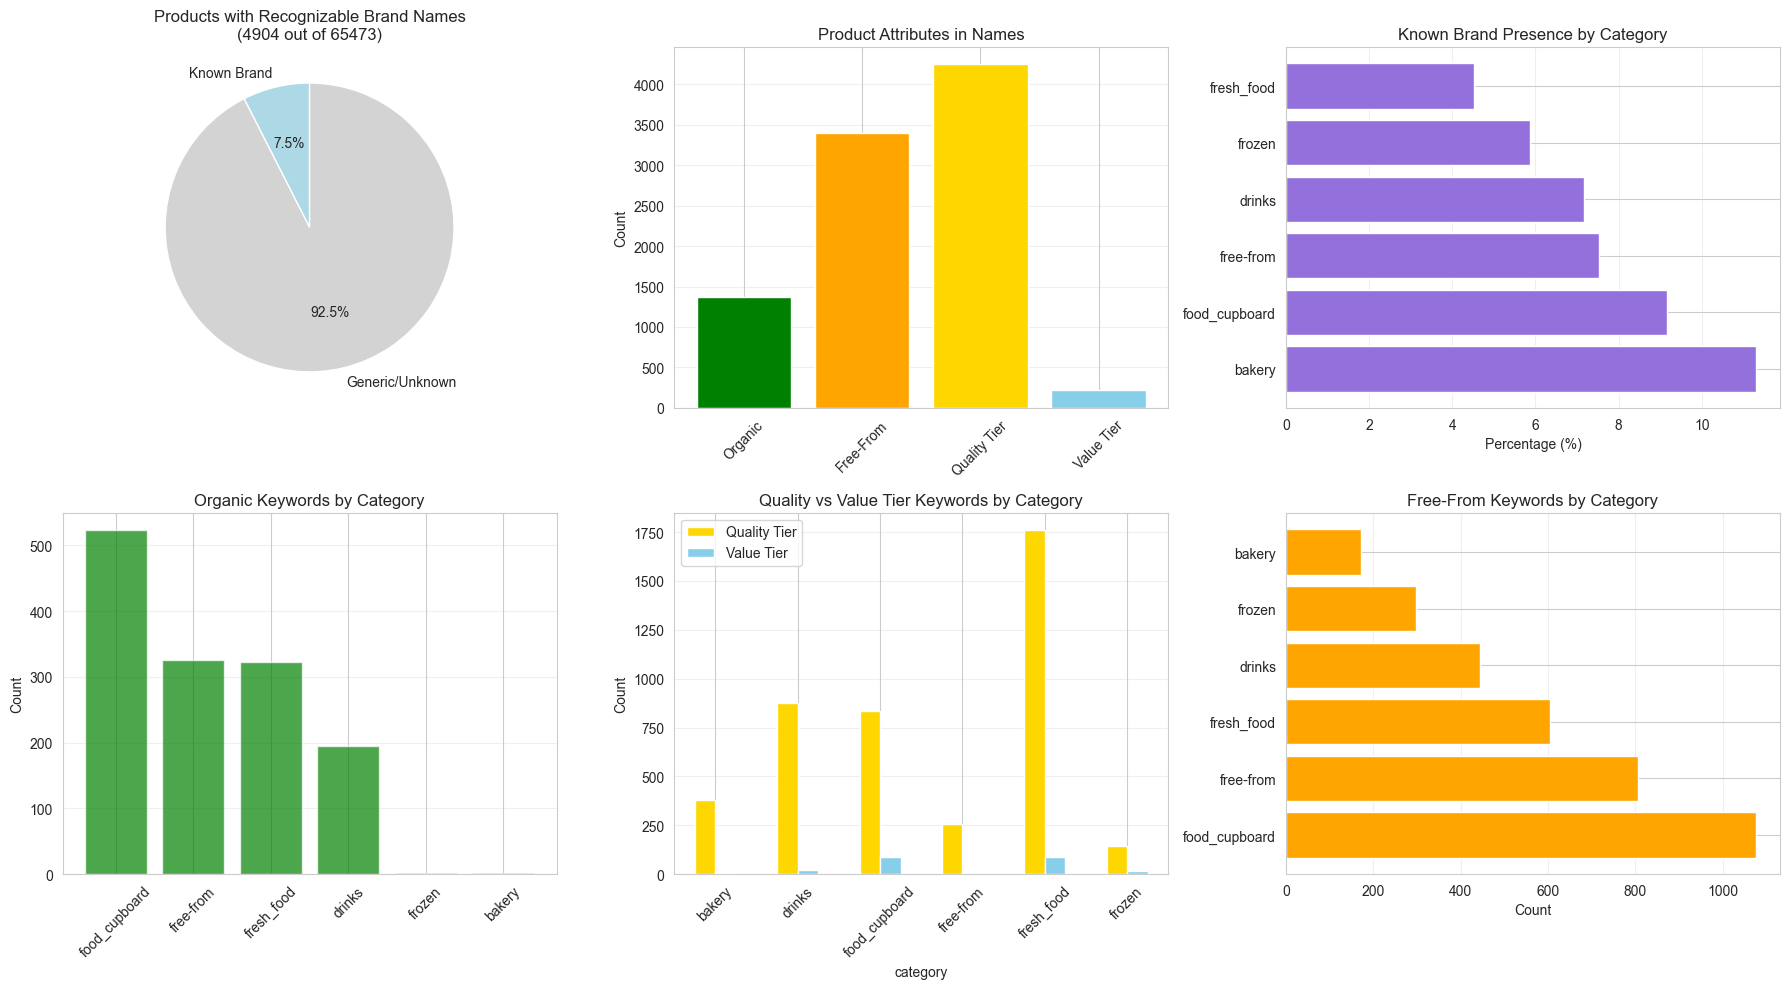


=== BRAND & ATTRIBUTE DETECTION STATISTICS ===
Products with known brand names: 4904 (7.49%)
Products with organic keywords: 1369 (2.09%)
Products with free-from keywords: 3401 (5.19%)
Products with quality tier keywords: 4246 (6.49%)
Products with value tier keywords: 223 (0.34%)

=== RELATIONSHIP BETWEEN OWN_BRAND FLAG AND DETECTED PATTERNS ===

Known Brand Detection vs Own_Brand Flag:
has_known_brand  False  True    All
own_brand                          
False            39888  4889  44777
True             20680    15  20695
All              60568  4904  65472

=== SAMPLE PRODUCTS WITH DIFFERENT ATTRIBUTES ===

With Known Brands:
                                                names own_brand
0              Tassimo Cadbury Hot Chocolate Pods x 8     False
2   Tassimo Limited Edition Cadbury Orange Hot Cho...     False
15                    Nescafe Original Instant Coffee     False
27                  Nescafe Gold Blend Instant Coffee     False
35             Nescafe Original Decaf

In [35]:
## 9. Brand & Product Attribute Detection

# Define common brand keywords and attributes
common_brands = ['coca-cola', 'pepsi', 'heinz', 'kellogg', "kellogg's", 'nestle', 'cadbury', 
                'walkers', 'pringles', 'doritos', 'ben & jerry', "ben & jerry's", 'haagen-dazs',
                'muller', 'yoplait', 'warburtons', 'hovis', 'lurpak', 'anchor', 'flora',
                'nescafe', 'twinings', 'tetley', 'ribena', 'robinsons', 'tropicana',
                'innocent', 'philadelphia', 'dairylea', 'müller', 'activia', 'danone']

organic_keywords = ['organic', 'bio', 'soil association']
free_from_keywords = ['free', 'gluten free', 'dairy free', 'vegan', 'vegetarian', 'plant-based']
quality_tiers = ['finest', 'extra special', 'taste the difference', 'the best', 'premium', 'luxury']
value_tiers = ['value', 'basics', 'savers', 'smart price', 'everyday']

# Detect patterns
df['has_known_brand'] = df['names'].apply(
    lambda x: any(brand in str(x).lower() for brand in common_brands) if pd.notna(x) else False
)

df['has_organic_keyword'] = df['names'].apply(
    lambda x: any(keyword in str(x).lower() for keyword in organic_keywords) if pd.notna(x) else False
)

df['has_free_from_keyword'] = df['names'].apply(
    lambda x: any(keyword in str(x).lower() for keyword in free_from_keywords) if pd.notna(x) else False
)

df['has_quality_tier'] = df['names'].apply(
    lambda x: any(tier in str(x).lower() for tier in quality_tiers) if pd.notna(x) else False
)

df['has_value_tier'] = df['names'].apply(
    lambda x: any(tier in str(x).lower() for tier in value_tiers) if pd.notna(x) else False
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Brand presence
brand_counts = {
    'Known Brand': df['has_known_brand'].sum(),
    'Generic/Unknown': (~df['has_known_brand']).sum()
}
axes[0, 0].pie(brand_counts.values(), labels=brand_counts.keys(), autopct='%1.1f%%',
               colors=['lightblue', 'lightgray'], startangle=90)
axes[0, 0].set_title(f'Products with Recognizable Brand Names\n({df["has_known_brand"].sum()} out of {len(df)})')

# Attribute detection
attribute_detection = {
    'Organic': df['has_organic_keyword'].sum(),
    'Free-From': df['has_free_from_keyword'].sum(),
    'Quality Tier': df['has_quality_tier'].sum(),
    'Value Tier': df['has_value_tier'].sum()
}
axes[0, 1].bar(attribute_detection.keys(), attribute_detection.values(), color=['green', 'orange', 'gold', 'skyblue'])
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Product Attributes in Names')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Brand presence by category
brand_by_category = df.groupby('category')['has_known_brand'].agg(['sum', 'count'])
brand_by_category['percentage'] = (brand_by_category['sum'] / brand_by_category['count'] * 100)
brand_by_category = brand_by_category.sort_values('percentage', ascending=False)

axes[0, 2].barh(brand_by_category.index, brand_by_category['percentage'], color='mediumpurple')
axes[0, 2].set_xlabel('Percentage (%)')
axes[0, 2].set_title('Known Brand Presence by Category')
axes[0, 2].grid(axis='x', alpha=0.3)

# Organic keywords by category
organic_by_category = df.groupby('category')['has_organic_keyword'].sum().sort_values(ascending=False)
axes[1, 0].bar(organic_by_category.index, organic_by_category.values, color='green', alpha=0.7)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Organic Keywords by Category')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Quality vs Value tiers
tier_comparison = pd.DataFrame({
    'Quality Tier': df.groupby('category')['has_quality_tier'].sum(),
    'Value Tier': df.groupby('category')['has_value_tier'].sum()
})
tier_comparison.plot(kind='bar', ax=axes[1, 1], color=['gold', 'skyblue'])
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Quality vs Value Tier Keywords by Category')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(loc='best')
axes[1, 1].grid(axis='y', alpha=0.3)

# Free-from keywords by category
freefrom_by_category = df.groupby('category')['has_free_from_keyword'].sum().sort_values(ascending=False)
axes[1, 2].barh(freefrom_by_category.index, freefrom_by_category.values, color='orange')
axes[1, 2].set_xlabel('Count')
axes[1, 2].set_title('Free-From Keywords by Category')
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== BRAND & ATTRIBUTE DETECTION STATISTICS ===")
print(f"Products with known brand names: {df['has_known_brand'].sum()} ({df['has_known_brand'].sum()/len(df)*100:.2f}%)")
print(f"Products with organic keywords: {df['has_organic_keyword'].sum()} ({df['has_organic_keyword'].sum()/len(df)*100:.2f}%)")
print(f"Products with free-from keywords: {df['has_free_from_keyword'].sum()} ({df['has_free_from_keyword'].sum()/len(df)*100:.2f}%)")
print(f"Products with quality tier keywords: {df['has_quality_tier'].sum()} ({df['has_quality_tier'].sum()/len(df)*100:.2f}%)")
print(f"Products with value tier keywords: {df['has_value_tier'].sum()} ({df['has_value_tier'].sum()/len(df)*100:.2f}%)")

print("\n=== RELATIONSHIP BETWEEN OWN_BRAND FLAG AND DETECTED PATTERNS ===")
print("\nKnown Brand Detection vs Own_Brand Flag:")
print(pd.crosstab(df['own_brand'], df['has_known_brand'], margins=True))

print("\n=== SAMPLE PRODUCTS WITH DIFFERENT ATTRIBUTES ===")
print("\nWith Known Brands:")
print(df[df['has_known_brand']][['names', 'own_brand']].head(5))
print("\nWith Organic Keywords:")
print(df[df['has_organic_keyword']][['names', 'category']].head(5))
print("\nWith Quality Tier:")
print(df[df['has_quality_tier']][['names', 'supermarket']].head(5))
print("\nWith Value Tier:")
print(df[df['has_value_tier']][['names', 'supermarket']].head(5))

=== SUPERMARKET-SPECIFIC NAME ANALYSIS ===


=== DISTINCTIVE WORDS BY SUPERMARKET (excl. brand names) ===

ASDA (n=17206):
------------------------------------------------------------
  home                 -  1006 occurrences (93.8% from ASDA)
  george               -   979 occurrences (100.0% from ASDA)
  extra                -   905 occurrences (65.0% from ASDA)
  special              -   759 occurrences (86.2% from ASDA)
  bakery               -   337 occurrences (84.5% from ASDA)
  mug                  -   252 occurrences (88.7% from ASDA)
  just                 -   243 occurrences (79.2% from ASDA)
  essentials           -   229 occurrences (99.6% from ASDA)

Morrisons (n=14462):
------------------------------------------------------------
  best                 -   696 occurrences (91.1% from Morrisons)
  20mg                 -   284 occurrences (100.0% from Morrisons)
  market               -   162 occurrences (95.9% from Morrisons)
  savers               -   146 occurrences (1

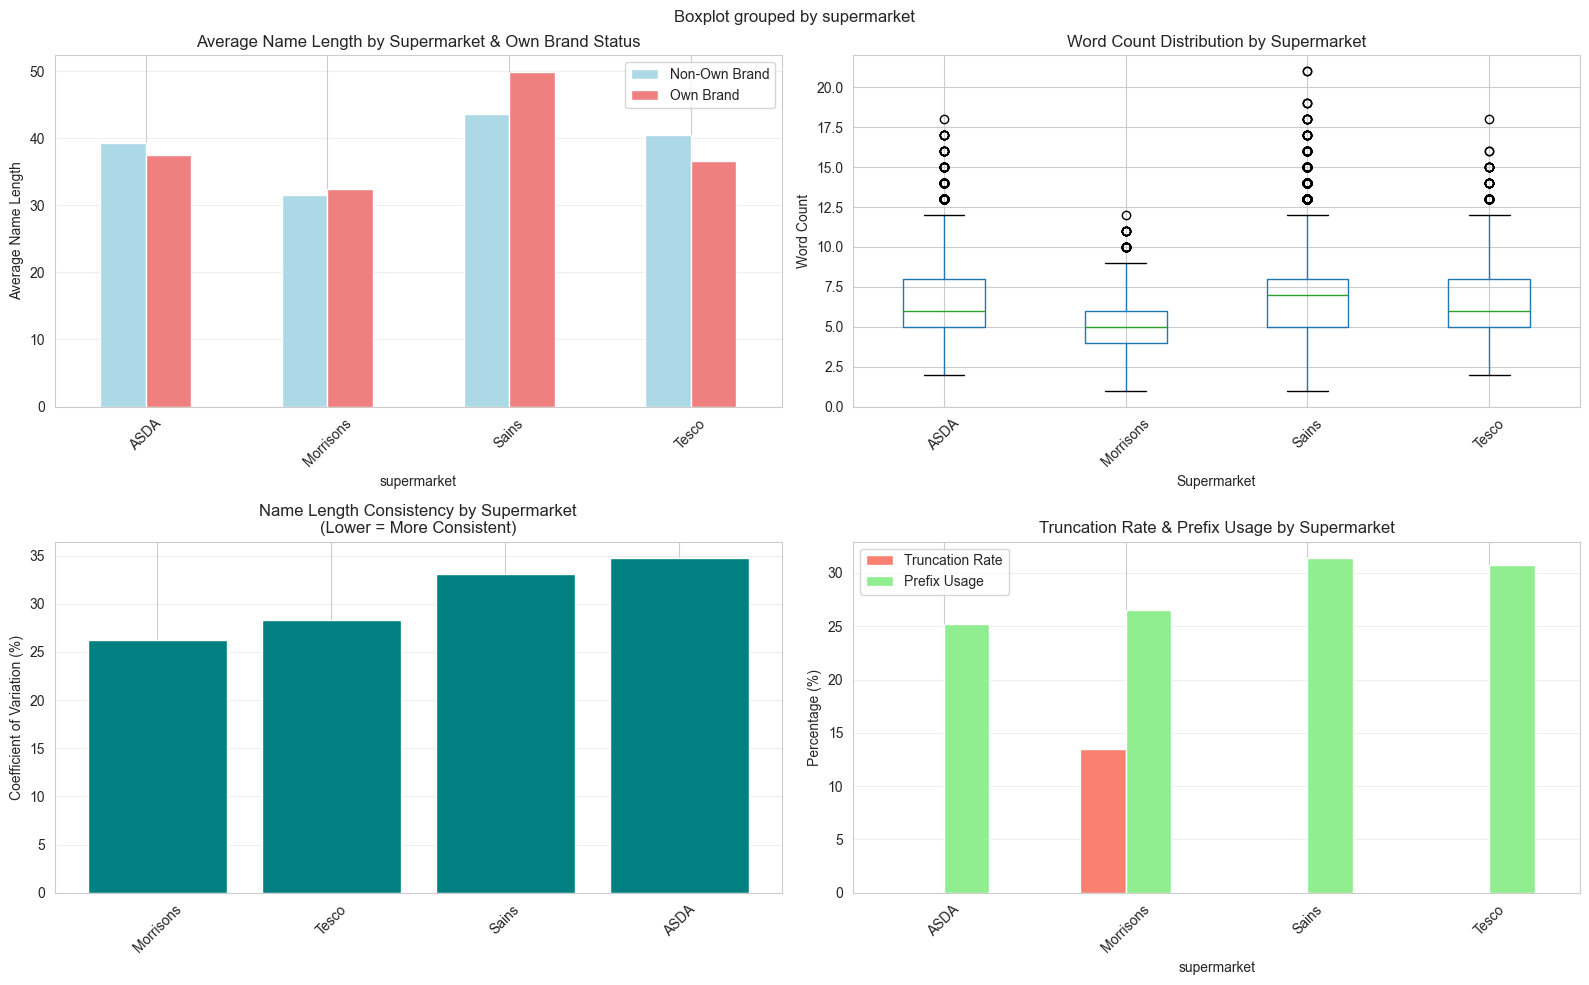



=== SUPERMARKET NAMING STATISTICS SUMMARY ===
             Avg Name Length  Name Length Std  Avg Word Count  \
supermarket                                                     
Sains                  45.58            15.08            7.01   
ASDA                   38.60            13.40            6.26   
Tesco                  39.32            11.13            6.47   
Morrisons              31.79             8.35            4.88   

             Avg Special Chars  Truncation %  Prefix %  Total Products  
supermarket                                                             
Sains                     0.93          0.00     31.36           17974  
ASDA                      0.43          0.00     25.18           17205  
Tesco                     0.34          0.00     30.71           15831  
Morrisons                 0.45         13.53     26.51           14462  


In [36]:
## 10. Supermarket-Specific Naming Convention Analysis

# Analyze naming patterns unique to each supermarket
supermarkets = df['supermarket'].unique()

print("=== SUPERMARKET-SPECIFIC NAME ANALYSIS ===\n")

# Get unique words per supermarket
supermarket_words = {}
for supermarket in supermarkets:
    sm_df = df[df['supermarket'] == supermarket]
    words = []
    for name in sm_df['names'].dropna():
        words.extend([w.lower() for w in str(name).split()])
    supermarket_words[supermarket] = Counter(words)

# Find supermarket-specific terms (words that appear significantly more in one supermarket)
print("\n=== DISTINCTIVE WORDS BY SUPERMARKET (excl. brand names) ===")
stop_words = {'tesco', 'asda', 'morrisons', 'sainsbury\'s', 'sainsburys', 'sains', 'the', 'a', 'an', 
              'and', 'or', 'of', 'in', 'with', '&', 'x', 'pack', 'g', 'kg', 'ml', 'l'}

for supermarket in supermarkets:
    total_products = len(df[df['supermarket'] == supermarket])
    print(f"\n{supermarket} (n={total_products}):")
    print("-" * 60)
    
    # Get words specific to this supermarket
    own_words = supermarket_words[supermarket]
    
    # Find distinctive words
    distinctive = []
    for word, count in own_words.most_common(100):
        if word.lower() not in stop_words and len(word) > 2:
            # Calculate what % of this word's occurrences are in this supermarket
            total_count = sum(supermarket_words[sm].get(word, 0) for sm in supermarkets)
            if total_count > 0:
                percentage = (count / total_count) * 100
                if percentage > 60:  # Word appears in >60% from this supermarket
                    distinctive.append((word, count, percentage))
    
    # Show top distinctive words
    for word, count, pct in sorted(distinctive, key=lambda x: x[1], reverse=True)[:10]:
        print(f"  {word:20s} - {count:5d} occurrences ({pct:.1f}% from {supermarket})")

# Create visualization comparing naming patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Average name length by supermarket and own_brand
name_length_comparison = df.groupby(['supermarket', 'own_brand'])['name_length'].mean().unstack()
name_length_comparison.plot(kind='bar', ax=axes[0, 0], color=['lightblue', 'lightcoral'])
axes[0, 0].set_ylabel('Average Name Length')
axes[0, 0].set_title('Average Name Length by Supermarket & Own Brand Status')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend(['Non-Own Brand', 'Own Brand'])
axes[0, 0].grid(axis='y', alpha=0.3)

# Word count distribution by supermarket
df.boxplot(column='word_count', by='supermarket', ax=axes[0, 1])
axes[0, 1].set_xlabel('Supermarket')
axes[0, 1].set_ylabel('Word Count')
axes[0, 1].set_title('Word Count Distribution by Supermarket')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# Naming pattern consistency (coefficient of variation of name length)
naming_consistency = df.groupby('supermarket')['name_length'].agg(['mean', 'std'])
naming_consistency['cv'] = (naming_consistency['std'] / naming_consistency['mean']) * 100
naming_consistency = naming_consistency.sort_values('cv')

axes[1, 0].bar(naming_consistency.index, naming_consistency['cv'], color='teal')
axes[1, 0].set_ylabel('Coefficient of Variation (%)')
axes[1, 0].set_title('Name Length Consistency by Supermarket\n(Lower = More Consistent)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Compare truncation and prefix usage
comparison_df = pd.DataFrame({
    'Truncation Rate': df.groupby('supermarket')['is_truncated'].mean() * 100,
    'Prefix Usage': df.groupby('supermarket')['has_own_prefix'].mean() * 100
})
comparison_df.plot(kind='bar', ax=axes[1, 1], color=['salmon', 'lightgreen'])
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Truncation Rate & Prefix Usage by Supermarket')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(loc='best')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n\n=== SUPERMARKET NAMING STATISTICS SUMMARY ===")
supermarket_summary = df.groupby('supermarket').agg({
    'name_length': ['mean', 'std'],
    'word_count': 'mean',
    'special_char_count': 'mean',
    'is_truncated': lambda x: x.sum() / len(x) * 100,
    'has_own_prefix': lambda x: x.sum() / len(x) * 100,
    'names': 'count'
}).round(2)

supermarket_summary.columns = ['Avg Name Length', 'Name Length Std', 'Avg Word Count', 
                                 'Avg Special Chars', 'Truncation %', 'Prefix %', 'Total Products']
print(supermarket_summary.sort_values('Total Products', ascending=False))

In [38]:
## 11. Summary Insights & Key Findings

print("=" * 80)
print("EXTENSIVE NAME ANALYSIS - KEY FINDINGS SUMMARY")
print("=" * 80)

print("\n1. DATASET OVERVIEW")
print("-" * 80)
print(f"   • Total products: {len(df):,}")
print(f"   • Unique product names: {df['names'].nunique():,}")
print(f"   • Uniqueness ratio: {df['names'].nunique() / len(df) * 100:.2f}%")
print(f"   • Date range: {df['date'].min()} to {df['date'].max()}")

print("\n2. NAME CHARACTERISTICS")
print("-" * 80)
print(f"   • Average name length: {df['name_length'].mean():.1f} characters (±{df['name_length'].std():.1f})")
print(f"   • Average word count: {df['word_count'].mean():.1f} words (±{df['word_count'].std():.1f})")
print(f"   • Names with numbers: {(df['number_count'] > 0).sum():,} ({(df['number_count'] > 0).sum()/len(df)*100:.1f}%)")
print(f"   • Names with special characters: {(df['special_char_count'] > 0).sum():,} ({(df['special_char_count'] > 0).sum()/len(df)*100:.1f}%)")

print("\n3. DATA QUALITY ISSUES")
print("-" * 80)
print(f"   • Truncated names: {df['is_truncated'].sum():,} ({df['is_truncated'].sum()/len(df)*100:.2f}%)")
print(f"   • Most affected supermarket: {df.groupby('supermarket')['is_truncated'].mean().idxmax()}")
print(f"   • Most affected category: {df.groupby('category')['is_truncated'].mean().idxmax()}")

print("\n4. BRAND & NAMING CONVENTIONS")
print("-" * 80)
print(f"   • Products with supermarket prefix: {df['has_own_prefix'].sum():,} ({df['has_own_prefix'].sum()/len(df)*100:.1f}%)")
print(f"   • Products with known brands: {df['has_known_brand'].sum():,} ({df['has_known_brand'].sum()/len(df)*100:.1f}%)")
print(f"   • Own brand products (flag): {df['own_brand'].sum():,} ({df['own_brand'].sum()/len(df)*100:.1f}%)")

print("\n5. PRODUCT ATTRIBUTES")
print("-" * 80)
print(f"   • Organic keywords: {df['has_organic_keyword'].sum():,} products")
print(f"   • Free-from keywords: {df['has_free_from_keyword'].sum():,} products")
print(f"   • Quality tier keywords: {df['has_quality_tier'].sum():,} products")
print(f"   • Value tier keywords: {df['has_value_tier'].sum():,} products")

print("\n6. UNIT/MEASUREMENT INFORMATION IN NAMES")
print("-" * 80)
print(f"   • Grams (g): {df['has_grams'].sum():,} ({df['has_grams'].sum()/len(df)*100:.1f}%)")
print(f"   • Kilograms (kg): {df['has_kilograms'].sum():,} ({df['has_kilograms'].sum()/len(df)*100:.1f}%)")
print(f"   • Milliliters (ml): {df['has_milliliters'].sum():,} ({df['has_milliliters'].sum()/len(df)*100:.1f}%)")
print(f"   • Liters (l): {df['has_liters'].sum():,} ({df['has_liters'].sum()/len(df)*100:.1f}%)")
print(f"   • Pack size info: {df['has_pack_size'].sum():,} ({df['has_pack_size'].sum()/len(df)*100:.1f}%)")

print("\n7. CROSS-SUPERMARKET COMPARISON")
print("-" * 80)
name_supermarket_counts = df.groupby('names')['supermarket'].nunique()
cross_supermarket_names = name_supermarket_counts[name_supermarket_counts > 1]
cross_supermarket_count = len(cross_supermarket_names)
total_cross_products = df['names'].isin(cross_supermarket_names.index).sum()

print(f"   • Names appearing in multiple supermarkets: {cross_supermarket_count:,}")
print(f"   • Products with cross-supermarket names: {total_cross_products:,}")

print("\n8. CATEGORY DISTRIBUTION")
print("-" * 80)
for category, count in df['category'].value_counts().items():
    print(f"   • {category.replace('_', ' ').title()}: {count:,} ({count/len(df)*100:.1f}%)")

print("\n9. RECOMMENDATIONS FOR CLEANING")
print("-" * 80)
print("   • Remove/standardize supermarket-specific prefixes (affects ~{}% of products)".format(
    round(df['has_own_prefix'].sum()/len(df)*100)))
print("   • Handle truncated names ({}% of dataset) - may need source data".format(
    round(df['is_truncated'].sum()/len(df)*100, 1)))
print("   • Standardize unit expressions (g, kg, ml, l) in names")
print("   • Normalize special characters and capitalization")
print("   • Extract and separate brand names from product descriptions")
print("   • Parse pack size information separately")
print("   • Create clean product identifiers without brand prefixes")

print("\n" + "=" * 80)

EXTENSIVE NAME ANALYSIS - KEY FINDINGS SUMMARY

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
   • Total products: 65,473
   • Unique product names: 63,275
   • Uniqueness ratio: 96.64%
   • Date range: 20240109 to 20240413

2. NAME CHARACTERISTICS
--------------------------------------------------------------------------------
   • Average name length: 39.2 characters (±13.4)
   • Average word count: 6.2 words (±2.2)
   • Names with numbers: 41,574 (63.5%)
   • Names with special characters: 25,371 (38.8%)

3. DATA QUALITY ISSUES
--------------------------------------------------------------------------------
   • Truncated names: 1,956 (2.99%)
   • Most affected supermarket: Morrisons
   • Most affected category: frozen

4. BRAND & NAMING CONVENTIONS
--------------------------------------------------------------------------------
   • Products with supermarket prefix: 18,663 (28.5%)
   • Products with known brands: 4,904 (7.5%)
 

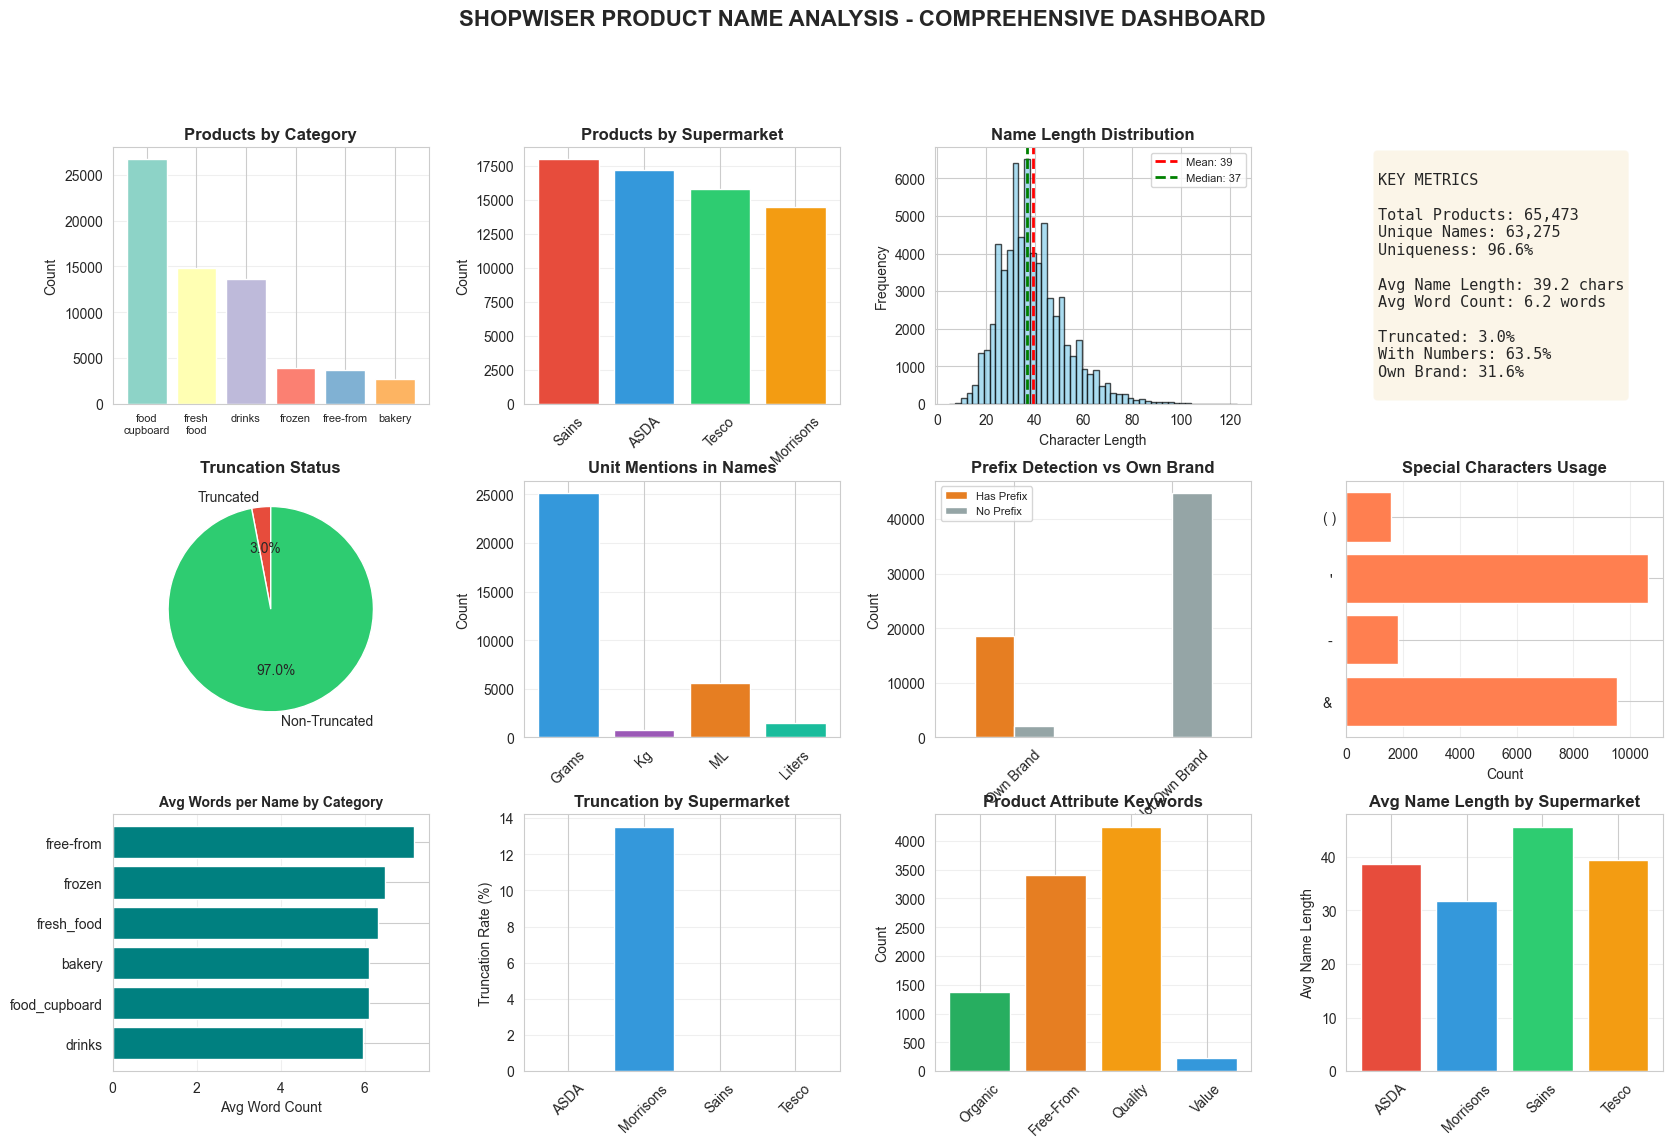


✓ Dashboard created successfully!
  This dashboard provides a comprehensive overview of all name analysis metrics.


In [40]:
## 12. Comprehensive Visualization Dashboard

# Create a comprehensive dashboard with the most important insights
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# 1. Category distribution
ax1 = fig.add_subplot(gs[0, 0])
category_counts = df['category'].value_counts()
ax1.bar(range(len(category_counts)), category_counts.values, color=plt.cm.Set3(range(len(category_counts))))
ax1.set_xticks(range(len(category_counts)))
ax1.set_xticklabels([c.replace('_', '\n') for c in category_counts.index], fontsize=8)
ax1.set_ylabel('Count')
ax1.set_title('Products by Category', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Supermarket distribution
ax2 = fig.add_subplot(gs[0, 1])
supermarket_counts = df['supermarket'].value_counts()
ax2.bar(supermarket_counts.index, supermarket_counts.values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
ax2.set_ylabel('Count')
ax2.set_title('Products by Supermarket', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Name length distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['name_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(df['name_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["name_length"].mean():.0f}')
ax3.axvline(df['name_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["name_length"].median():.0f}')
ax3.set_xlabel('Character Length')
ax3.set_ylabel('Frequency')
ax3.set_title('Name Length Distribution', fontweight='bold')
ax3.legend(fontsize=8)

# 4. Key metrics summary
ax4 = fig.add_subplot(gs[0, 3])
ax4.axis('off')
metrics_text = f"""
KEY METRICS

Total Products: {len(df):,}
Unique Names: {df['names'].nunique():,}
Uniqueness: {df['names'].nunique()/len(df)*100:.1f}%

Avg Name Length: {df['name_length'].mean():.1f} chars
Avg Word Count: {df['word_count'].mean():.1f} words

Truncated: {df['is_truncated'].sum()/len(df)*100:.1f}%
With Numbers: {(df['number_count']>0).sum()/len(df)*100:.1f}%
Own Brand: {df['own_brand'].sum()/len(df)*100:.1f}%
"""
ax4.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center', 
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 5. Data quality issues
ax5 = fig.add_subplot(gs[1, 0])
quality_issues = {
    'Truncated': df['is_truncated'].sum(),
    'Non-Truncated': len(df) - df['is_truncated'].sum()
}
colors_quality = ['#e74c3c', '#2ecc71']
ax5.pie(quality_issues.values(), labels=quality_issues.keys(), autopct='%1.1f%%',
        colors=colors_quality, startangle=90)
ax5.set_title('Truncation Status', fontweight='bold')

# 6. Unit patterns
ax6 = fig.add_subplot(gs[1, 1])
unit_data = {
    'Grams': df['has_grams'].sum(),
    'Kg': df['has_kilograms'].sum(),
    'ML': df['has_milliliters'].sum(),
    'Liters': df['has_liters'].sum()
}
ax6.bar(unit_data.keys(), unit_data.values(), color=['#3498db', '#9b59b6', '#e67e22', '#1abc9c'])
ax6.set_ylabel('Count')
ax6.set_title('Unit Mentions in Names', fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(axis='y', alpha=0.3)

# 7. Brand analysis
ax7 = fig.add_subplot(gs[1, 2])

# Pre-calculate masks to avoid repetition and handle NaNs
has_prefix = df['has_own_prefix'].fillna(False).astype(bool)
is_own_brand = df['own_brand'].fillna(False).astype(bool)

brand_data = pd.DataFrame({
    'Has Prefix': [
        (has_prefix & is_own_brand).sum(), 
        (has_prefix & ~is_own_brand).sum()
    ],
    'No Prefix': [
        (~has_prefix & is_own_brand).sum(),
        (~has_prefix & ~is_own_brand).sum()
    ]
}, index=['Own Brand', 'Not Own Brand'])

brand_data.plot(kind='bar', ax=ax7, color=['#e67e22', '#95a5a6'])
ax7.set_ylabel('Count')
ax7.set_title('Prefix Detection vs Own Brand', fontweight='bold')
ax7.tick_params(axis='x', rotation=45)
ax7.legend(fontsize=8)
ax7.grid(axis='y', alpha=0.3)

# 8. Special characters
ax8 = fig.add_subplot(gs[1, 3])
special_data = {
    '& ': df['has_ampersand'].sum(),
    '- ': df['has_hyphen'].sum(),
    '\' ': df['has_apostrophe'].sum(),
    '( )': df['has_parentheses'].sum()
}
ax8.barh(list(special_data.keys()), list(special_data.values()), color='coral')
ax8.set_xlabel('Count')
ax8.set_title('Special Characters Usage', fontweight='bold')
ax8.grid(axis='x', alpha=0.3)

# 9. Word count by category
ax9 = fig.add_subplot(gs[2, 0])
word_count_by_cat = df.groupby('category')['word_count'].mean().sort_values()
ax9.barh(word_count_by_cat.index, word_count_by_cat.values, color='teal')
ax9.set_xlabel('Avg Word Count')
ax9.set_title('Avg Words per Name by Category', fontweight='bold', fontsize=10)
ax9.grid(axis='x', alpha=0.3)

# 10. Truncation by supermarket
ax10 = fig.add_subplot(gs[2, 1])
trunc_by_sm = df.groupby('supermarket')['is_truncated'].mean() * 100
ax10.bar(trunc_by_sm.index, trunc_by_sm.values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
ax10.set_ylabel('Truncation Rate (%)')
ax10.set_title('Truncation by Supermarket', fontweight='bold')
ax10.tick_params(axis='x', rotation=45)
ax10.grid(axis='y', alpha=0.3)

# 11. Product attributes
ax11 = fig.add_subplot(gs[2, 2])
attributes = {
    'Organic': df['has_organic_keyword'].sum(),
    'Free-From': df['has_free_from_keyword'].sum(),
    'Quality': df['has_quality_tier'].sum(),
    'Value': df['has_value_tier'].sum()
}
ax11.bar(attributes.keys(), attributes.values(), 
         color=['#27ae60', '#e67e22', '#f39c12', '#3498db'])
ax11.set_ylabel('Count')
ax11.set_title('Product Attribute Keywords', fontweight='bold')
ax11.tick_params(axis='x', rotation=45)
ax11.grid(axis='y', alpha=0.3)

# 12. Name length by supermarket
ax12 = fig.add_subplot(gs[2, 3])
name_len_by_sm = df.groupby('supermarket')['name_length'].mean()
ax12.bar(name_len_by_sm.index, name_len_by_sm.values, 
         color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
ax12.set_ylabel('Avg Name Length')
ax12.set_title('Avg Name Length by Supermarket', fontweight='bold')
ax12.tick_params(axis='x', rotation=45)
ax12.grid(axis='y', alpha=0.3)

fig.suptitle('SHOPWISER PRODUCT NAME ANALYSIS - COMPREHENSIVE DASHBOARD', 
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

print("\n✓ Dashboard created successfully!")
print("  This dashboard provides a comprehensive overview of all name analysis metrics.")

In [41]:
## 13. Export Enhanced Dataset

# List all new features created during analysis
new_features = [
    'name_length', 'word_count', 'is_truncated', 'has_own_prefix',
    'extracted_numbers', 'number_count', 'has_grams', 'has_kilograms',
    'has_milliliters', 'has_liters', 'has_pack_size', 'has_percentage',
    'has_ampersand', 'has_hyphen', 'has_apostrophe', 'has_comma',
    'has_parentheses', 'has_slash', 'has_plus', 'uppercase_count',
    'lowercase_count', 'digit_count', 'special_char_count', 'is_all_caps',
    'is_title_case', 'starts_with_capital', 'has_known_brand',
    'has_organic_keyword', 'has_free_from_keyword', 'has_quality_tier',
    'has_value_tier'
]

print("=" * 80)
print("ENHANCED DATASET EXPORT")
print("=" * 80)
print(f"\nOriginal features: {len(df.columns) - len(new_features)}")
print(f"New features added: {len(new_features)}")
print(f"Total features: {len(df.columns)}")

print("\nNew features created:")
for i, feature in enumerate(new_features, 1):
    print(f"  {i:2d}. {feature}")

# Save enhanced dataset
output_path = 'eda/enhanced_raw_with_name_features.csv'
df.to_csv(output_path, index=False)
print(f"\n✓ Enhanced dataset saved to: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Size: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Create a data dictionary
data_dict = {
    'Feature': [],
    'Type': [],
    'Description': []
}

feature_descriptions = {
    'supermarket': 'Supermarket name (Tesco, ASDA, Morrisons, Sains)',
    'prices_(£)': 'Product price in pounds',
    'prices_unit_(£)': 'Unit price in pounds',
    'unit': 'Unit of measurement (kg, l, unit, m)',
    'names': 'Original product name',
    'date': 'Date of data collection',
    'category': 'Product category',
    'own_brand': 'Boolean flag for own brand products',
    'name_length': 'Character length of product name',
    'word_count': 'Number of words in product name',
    'is_truncated': 'Whether name is truncated (ends with ... or …)',
    'has_own_prefix': 'Whether name starts with supermarket-specific prefix',
    'extracted_numbers': 'List of all numbers found in name',
    'number_count': 'Count of numbers in name',
    'has_grams': 'Whether name contains grams unit (g)',
    'has_kilograms': 'Whether name contains kilograms unit (kg)',
    'has_milliliters': 'Whether name contains milliliters unit (ml)',
    'has_liters': 'Whether name contains liters unit (l)',
    'has_pack_size': 'Whether name mentions pack size (x6, pack of 4, etc.)',
    'has_percentage': 'Whether name contains percentage value',
    'has_ampersand': 'Whether name contains & character',
    'has_hyphen': 'Whether name contains - character',
    'has_apostrophe': 'Whether name contains \' character',
    'has_comma': 'Whether name contains , character',
    'has_parentheses': 'Whether name contains parentheses',
    'has_slash': 'Whether name contains / character',
    'has_plus': 'Whether name contains + character',
    'uppercase_count': 'Count of uppercase letters',
    'lowercase_count': 'Count of lowercase letters',
    'digit_count': 'Count of digit characters',
    'special_char_count': 'Count of special characters',
    'is_all_caps': 'Whether entire name is uppercase',
    'is_title_case': 'Whether name is in title case',
    'starts_with_capital': 'Whether name starts with capital letter',
    'has_known_brand': 'Whether name contains a recognized brand',
    'has_organic_keyword': 'Whether name contains organic keywords',
    'has_free_from_keyword': 'Whether name contains free-from keywords',
    'has_quality_tier': 'Whether name contains quality tier keywords',
    'has_value_tier': 'Whether name contains value tier keywords'
}

for col in df.columns:
    data_dict['Feature'].append(col)
    data_dict['Type'].append(str(df[col].dtype))
    data_dict['Description'].append(feature_descriptions.get(col, 'N/A'))

dict_df = pd.DataFrame(data_dict)
dict_path = 'eda/data_dictionary.csv'
dict_df.to_csv(dict_path, index=False)
print(f"\n✓ Data dictionary saved to: {dict_path}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("\nThe enhanced dataset is ready for the next stage: product clustering and categorization.")
print("Key insights have been visualized and documented for reference.")

ENHANCED DATASET EXPORT

Original features: 10
New features added: 31
Total features: 41

New features created:
   1. name_length
   2. word_count
   3. is_truncated
   4. has_own_prefix
   5. extracted_numbers
   6. number_count
   7. has_grams
   8. has_kilograms
   9. has_milliliters
  10. has_liters
  11. has_pack_size
  12. has_percentage
  13. has_ampersand
  14. has_hyphen
  15. has_apostrophe
  16. has_comma
  17. has_parentheses
  18. has_slash
  19. has_plus
  20. uppercase_count
  21. lowercase_count
  22. digit_count
  23. special_char_count
  24. is_all_caps
  25. is_title_case
  26. starts_with_capital
  27. has_known_brand
  28. has_organic_keyword
  29. has_free_from_keyword
  30. has_quality_tier
  31. has_value_tier

✓ Enhanced dataset saved to: eda/enhanced_raw_with_name_features.csv
  Shape: (65473, 41)
  Size: 32.62 MB

✓ Data dictionary saved to: eda/data_dictionary.csv

ANALYSIS COMPLETE

The enhanced dataset is ready for the next stage: product clustering and ca